# 07 — Investigación: preprocesado financiero

**Práctica B3-T4 · Forecasting financiero multivariante (SP500, 23 activos)**

Notebook de **investigación** del taller. La competición está cerrada en [`06_mixtos.ipynb`](06_mixtos.ipynb) (mejor mixto en test: `mixto_profMIX_in90_out90` con `MAE = 0.001277`, batiendo al MLP por 14%). Aquí exploramos si **preprocesados financieros** pueden mejorar aún más ese resultado.

## Marco metodológico

Aplicamos **12 técnicas de preprocesado** organizadas en 3 fases. Cada técnica se re-entrena sobre una sub-matriz representativa de **4 combinaciones críticas × 2 variantes top**, y se reporta el delta de MAE vs el baseline.

```mermaid
flowchart TD
    A["Baseline: returns log + StandardScaler"] --> B[Fase A: Workshop 1 transfer]
    A --> C[Fase B: Clasicos financieros]
    A --> D["Fase C: Lopez de Prado"]
    B --> E["A1 PCA, A2 Split temporal, A3 Composite, A4 DBSCAN outliers"]
    C --> F["B1 Returns simples, B2 Rolling 252d, B3 Vol EWMA, B4 Momentum ROC"]
    D --> G["C1 Fractional diff, C2 Purged k-fold, C3 Sample weights, C4 Triple barrier"]
    E --> H[Tabla maestra resultados x combinacion]
    F --> H
    G --> H
    H --> I[Heatmap mejora vs baseline]
    I --> J[Conclusiones por preprocesado]
```

## Separación competición ↔ investigación

| Aspecto | Competición ([`06_mixtos.ipynb`](06_mixtos.ipynb)) | Investigación (este notebook) |
|---|---|---|
| Datos | yfinance + log returns | **Permitido modificar el preprocesado** |
| Split | `split_triple` aleatorio | Permitido **temporal puro** |
| Target | Media a `output_window` días | Permitido **alternativo** (triple barrier) |
| Métrica | MAE | MAE + diagnósticos |
| Hiperparámetros | Tuneados solo con `val` | Igual + grids extra justificados |
| Output | `mixtos_resultados.csv` | `investigacion_resultados.csv` separado |

## Justificación del Workshop 1

Las técnicas A vienen del Taller 1 del bloque 3 ([`ML Workshop Part 1 of 2 Albert Martin.ipynb`](Taller%201%20Procesado%20de%20datos%20financieros/ML%20Workshop%20Part%201%20of%202%20Albert%20Martin.ipynb) y [Part 2](Taller%201%20Procesado%20de%20datos%20financieros/ML%20Workshop%20Part%202%20of%202%20Albert%20Martin.ipynb)). Las técnicas B son clásicos financieros estándar. Las C extienden la literatura del Taller 1 con **López de Prado (Advances in Financial ML)**, particularmente cap. 4 (sample weights), cap. 5 (fractional differentiation) y cap. 7 (purged CV).

## Índice

1. **Setup** — imports, semillas, paths.
2. **Configuración experimental** — 4 combinaciones críticas, 2 variantes, baseline.
3. **Datos** — carga del parquet cacheado por `06_mixtos`.
4. **Funciones reutilizadas** — `create_time_series_data`, `mae`, `split_triple`, `fit_scalers`, build de las 2 variantes top.
5. **Pipeline de experimentación** — `run_experiment` genérico; CSV unificado.
6. **Baseline** — Re-entrenar las 8 configuraciones sin preprocesado adicional.
7. **Fase A — Workshop 1 transfer** (A1 a A4).
8. **Fase B — Clásicos financieros** (B1 a B4).
9. **Fase C — López de Prado** (C1 a C4).
10. **Agregación y comparativas** — heatmap mejora, bar chart, tabla pivote.
11. **Conclusiones** — qué preprocesado funciona en qué celda.
12. **Validación final** — checklist + cheat sheet.

## 1. Setup

Replicamos las semillas, paths y patrón de imports de [`06_mixtos.ipynb`](06_mixtos.ipynb) para garantizar que el split, los scalers y los datos sean estrictamente comparables.

In [13]:
import os
import json
import time
import pickle
import random
import warnings
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

import tensorflow as tf
from tensorflow.keras import Model, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    LSTM, GRU,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TerminateOnNaN,
)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

RANDOM_SEED = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
print(f"TensorFlow {tf.__version__}  GPU={'si' if gpus else 'no'}")

mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["font.size"] = 9
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.3

TensorFlow 2.21.0  GPU=no


In [14]:
def _resolve_dir(name: str) -> Path:
    """Devuelve la primera carpeta existente entre ./<name>, ../<name>; si no existe la crea."""
    for cand in [Path(name), Path("..") / name]:
        if cand.exists():
            return cand.resolve()
    here = Path(name)
    here.mkdir(parents=True, exist_ok=True)
    return here.resolve()


RESULTS_DIR = _resolve_dir("results")
MODELS_DIR = _resolve_dir("models")
DATA_DIR = _resolve_dir("data")
LOGS_DIR = (RESULTS_DIR / "training_logs").resolve()
LOGS_DIR.mkdir(parents=True, exist_ok=True)

INV_CSV = RESULTS_DIR / "investigacion_resultados.csv"
INV_INDEX = RESULTS_DIR / "investigacion_index.json"
INV_HIST = RESULTS_DIR / "investigacion_historiales.pkl"

INPUT_WINDOWS = [5, 10, 30, 90]
OUTPUT_WINDOWS = [1, 5, 30, 90]
N_ASSETS = 23

print(f"RESULTS_DIR : {RESULTS_DIR}")
print(f"MODELS_DIR  : {MODELS_DIR}")
print(f"DATA_DIR    : {DATA_DIR}")

RESULTS_DIR : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results
MODELS_DIR  : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\models
DATA_DIR    : C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\data


## 2. Configuración experimental

**Submatriz crítica**: 4 combinaciones × 2 variantes top = **8 configuraciones** por técnica.

- Combinaciones: `(30,30)`, `(30,90)`, `(90,30)`, `(90,90)` — las celdas donde el mixto sí supera al MLP y donde el target tiene mayor estabilidad estadística.
- Variantes: `profMIX` (top-1 absoluto) y `convLSTM_causal` (top-2 con padding causal). Cubre dos paradigmas distintos del notebook 06.

Con **12 técnicas + baseline = 13 experimentos × 8 configs = 104 entrenamientos**, a ~1 min/modelo ≈ **~2 horas** total. Ejecución overnight cómoda.

In [15]:
COMBOS_CRITICOS = [(30, 30), (30, 90), (90, 30), (90, 90)]
VARIANTES_TOP = ["profMIX", "convLSTM_causal"]
PATIENCE_ES = 12
PATIENCE_RLR = 4
MAX_EPOCHS = {5: 150, 10: 150, 30: 200, 90: 250}

print(f"Combos criticos: {COMBOS_CRITICOS}")
print(f"Variantes top  : {VARIANTES_TOP}")
print(f"Total configs por tecnica: {len(COMBOS_CRITICOS) * len(VARIANTES_TOP)}")

Combos criticos: [(30, 30), (30, 90), (90, 30), (90, 90)]
Variantes top  : ['profMIX', 'convLSTM_causal']
Total configs por tecnica: 8


## 3. Carga de datos

Reutilizamos el parquet cacheado por `06_mixtos.ipynb` (`data/sp500_returns.parquet`). Si no existe, descargamos con yfinance. Esto garantiza que los datos sean **idénticos bit-a-bit** al pipeline de competición.

In [16]:
CACHE_RETURNS = DATA_DIR / "sp500_returns.parquet"
CACHE_PRICES = DATA_DIR / "sp500_close.parquet"

START_DATE = "1945-01-01"
TICKERS = [
    "AEP", "BA", "CAT", "CNP", "CVX", "DIS", "DTE", "ED", "GD", "GE",
    "HON", "HPQ", "IBM", "IP", "JNJ", "KO", "KR", "MMM", "MO", "MRK",
    "MSI", "PG", "XOM",
]


def load_returns_and_prices():
    """Carga retornos log + precios (necesarios para Fase B precios->returns simples y Fase C frac_diff)."""
    def _read(p):
        try:
            return pd.read_parquet(p)
        except Exception:
            with open(p.with_suffix(".pkl"), "rb") as f:
                return pickle.load(f)

    returns = None
    prices = None

    if CACHE_RETURNS.exists() or CACHE_RETURNS.with_suffix(".pkl").exists():
        path = CACHE_RETURNS if CACHE_RETURNS.exists() else CACHE_RETURNS.with_suffix(".pkl")
        returns = _read(path)
        print(f"[cache] retornos leidos shape={returns.shape}")

    if CACHE_PRICES.exists() or CACHE_PRICES.with_suffix(".pkl").exists():
        path = CACHE_PRICES if CACHE_PRICES.exists() else CACHE_PRICES.with_suffix(".pkl")
        prices = _read(path)
        print(f"[cache] precios leidos shape={prices.shape}")

    if returns is None or prices is None:
        import yfinance as yf
        print(f"[yfinance] descargando {len(TICKERS)} tickers desde {START_DATE} ...")
        prices = yf.download(TICKERS, start=START_DATE, auto_adjust=True, progress=False)["Close"]
        prices = prices.dropna(axis=1)
        try:
            prices.to_parquet(CACHE_PRICES)
        except Exception:
            with open(CACHE_PRICES.with_suffix(".pkl"), "wb") as f:
                pickle.dump(prices, f)
        returns = np.log(prices / prices.shift(1)).dropna()
        try:
            returns.to_parquet(CACHE_RETURNS)
        except Exception:
            with open(CACHE_RETURNS.with_suffix(".pkl"), "wb") as f:
                pickle.dump(returns, f)

    common_idx = returns.index.intersection(prices.index)
    prices = prices.loc[common_idx]
    returns = returns.loc[returns.index.intersection(common_idx)]
    return returns, prices


returns_df, prices_df = load_returns_and_prices()
print()
print(f"returns_df shape: {returns_df.shape}    fechas: {returns_df.index.min().date()} -> {returns_df.index.max().date()}")
print(f"prices_df  shape: {prices_df.shape}     fechas: {prices_df.index.min().date()} -> {prices_df.index.max().date()}")
print(f"Activos ({len(returns_df.columns)}): {list(returns_df.columns)}")

[cache] retornos leidos shape=(16200, 23)
[cache] precios leidos shape=(16201, 23)

returns_df shape: (16200, 23)    fechas: 1962-01-03 -> 2026-05-15
prices_df  shape: (16200, 23)     fechas: 1962-01-03 -> 2026-05-15
Activos (23): ['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


## 4. Funciones reutilizadas del notebook 06

`create_time_series_data`, `mae`, `split_triple`, scalers y dos build adaptados para aceptar **número de canales arbitrario** (necesario para PCA y para canales extra como EWMA/ROC).

In [17]:
def create_time_series_data(data, input_window_size, output_window_size, target_data=None):
    """Genera X (n, in, ch) e y (n, out_ch) con target = media de los siguientes output_window dias.

    Si `target_data` es None, target se calcula sobre `data` (mismo array que X).
    Permite preprocesar X y mantener target sobre los retornos originales (necesario para investigacion).
    """
    X, y = [], []
    src = data.values if isinstance(data, pd.DataFrame) else data
    tgt = target_data.values if isinstance(target_data, pd.DataFrame) else (target_data if target_data is not None else src)
    n_total = min(len(src), len(tgt))
    for i in range(n_total - input_window_size - output_window_size + 1):
        X.append(src[i : i + input_window_size])
        y.append(np.mean(tgt[i + input_window_size : i + input_window_size + output_window_size], axis=0))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))


def mae_by_asset(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred), axis=0)


def split_triple(X, y, test_size=0.1, val_size=0.1, random_state=RANDOM_SEED):
    """Test cronologico (shuffle=False) + train/val aleatorio. Identico a 06_mixtos."""
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=test_size, shuffle=False)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=val_size, shuffle=True, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def split_triple_temporal(X, y, test_size=0.1, val_size=0.1):
    """Variante A2: validacion tambien cronologica (bloque entre train y test). SIN shuffle.

    Estructura: |---- train ----|-- val --|-- test --|
    """
    n = len(X)
    n_test = int(n * test_size)
    n_val = int(n * val_size)
    X_train = X[: n - n_test - n_val]
    y_train = y[: n - n_test - n_val]
    X_val = X[n - n_test - n_val : n - n_test]
    y_val = y[n - n_test - n_val : n - n_test]
    X_test = X[n - n_test :]
    y_test = y[n - n_test :]
    return X_train, X_val, X_test, y_train, y_val, y_test


def fit_scalers(X_train, y_train):
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    n, in_w, ch = X_train.shape
    scaler_X.fit(X_train.reshape(-1, ch))
    scaler_y.fit(y_train)
    return scaler_X, scaler_y


def apply_scaler_X(scaler_X, X):
    n, in_w, ch = X.shape
    return scaler_X.transform(X.reshape(-1, ch)).reshape(n, in_w, ch).astype(np.float32)


def apply_scaler_y(scaler_y, y):
    return scaler_y.transform(y).astype(np.float32)


def inverse_y(scaler_y, y_norm):
    return scaler_y.inverse_transform(y_norm)

In [18]:
def build_profMIX(input_window, output_window, n_in_channels, n_out=N_ASSETS):
    """V1 profMIX adaptado a numero de canales de entrada arbitrario.

    LSTM(64) -> GRU(64) -> Conv1D -> MaxPool -> [opcional Conv1D + MaxPool] -> Flatten -> Dense(n_out).
    """
    if input_window <= 5:
        filters, kernel, n_pools, lstm_units, gru_units = 16, 2, 1, 32, 32
    elif input_window <= 10:
        filters, kernel, n_pools, lstm_units, gru_units = 16, 3, 1, 32, 32
    elif input_window <= 30:
        filters, kernel, n_pools, lstm_units, gru_units = 32, 5, 2, 64, 64
    else:
        filters, kernel, n_pools, lstm_units, gru_units = 64, 5, 2, 64, 64

    layers_list = [
        Input(shape=(input_window, n_in_channels)),
        LSTM(lstm_units, return_sequences=True, dropout=0.2, recurrent_dropout=0.0),
        GRU(gru_units, return_sequences=True),
        Conv1D(filters, kernel_size=kernel, activation="relu", padding="same"),
        MaxPooling1D(pool_size=2),
    ]
    if n_pools >= 2:
        layers_list += [
            Conv1D(filters, kernel_size=kernel, activation="relu", padding="same"),
            MaxPooling1D(pool_size=2),
        ]
    layers_list += [Flatten(), Dense(n_out, activation="linear")]
    return Sequential(layers_list, name=f"profMIX_in{input_window}_out{output_window}_ch{n_in_channels}")


def build_convLSTM_causal(input_window, output_window, n_in_channels, n_out=N_ASSETS):
    """V2 convLSTM_causal con padding causal + BN, adaptado a canales arbitrarios."""
    if input_window <= 5:
        kernel, conv_filters, lstm_units, dense_units = 2, 32, 32, 32
    elif input_window <= 10:
        kernel, conv_filters, lstm_units, dense_units = 3, 32, 32, 32
    else:
        kernel, conv_filters, lstm_units, dense_units = 3, 64, 64, 64

    return Sequential(
        [
            Input(shape=(input_window, n_in_channels)),
            Conv1D(conv_filters, kernel_size=kernel, padding="causal", activation="relu"),
            BatchNormalization(),
            Conv1D(conv_filters, kernel_size=kernel, padding="causal", activation="relu"),
            BatchNormalization(),
            LSTM(lstm_units),
            Dropout(0.2),
            Dense(dense_units, activation="relu"),
            Dense(n_out, activation="linear"),
        ],
        name=f"convLSTM_causal_in{input_window}_out{output_window}_ch{n_in_channels}",
    )


VARIANTES_BUILD = {
    "profMIX": build_profMIX,
    "convLSTM_causal": build_convLSTM_causal,
}


def get_lr_for(variante, input_window, output_window):
    base = 5e-4 if variante == "profMIX" else 1e-3
    if input_window >= 90:
        base *= 0.5
    if output_window == 1:
        base *= 0.5
    return float(base)


def get_batch_size_for(input_window):
    if input_window <= 10:
        return 128
    if input_window <= 30:
        return 64
    return 32

## 5. Funciones de preprocesado

Una función por técnica. Todas reciben los splits **post-creación de ventanas** (`X_train`, `X_val`, `X_test`) y devuelven versiones transformadas con la misma estructura.

Convención de **anti-leakage**: cualquier estadístico (medias, desviaciones, componentes PCA, etc.) se ajusta SOLO con `X_train`, y se aplica al val/test.

In [19]:
def apply_pca_channels(X_train, X_val, X_test, k):
    """A1 PCA cross-sectional: reduce los 23 canales a k componentes principales.

    PCA se ajusta en X_train (aplanando todos los timesteps en uno solo cross-sectional).
    Cada paso temporal de cada ventana se proyecta sobre los k autovectores.
    Salida shape: (n, in, k).
    """
    n_train, in_w, ch = X_train.shape
    pca = PCA(n_components=k, random_state=RANDOM_SEED)
    pca.fit(X_train.reshape(-1, ch))

    def _proj(X):
        n, in_w, ch = X.shape
        return pca.transform(X.reshape(-1, ch)).reshape(n, in_w, k).astype(np.float32)

    return _proj(X_train), _proj(X_val), _proj(X_test), pca


def make_rolling_norm_features(returns, lookback=252):
    """B2 Normalizacion rolling 252d sobre la serie completa de retornos.

    z_t = (r_t - mean_{t-lookback..t-1}) / std_{t-lookback..t-1}
    Devuelve un DataFrame del mismo shape que `returns` (con NaNs en los primeros lookback puntos).
    """
    roll_mean = returns.rolling(lookback, min_periods=lookback).mean().shift(1)
    roll_std = returns.rolling(lookback, min_periods=lookback).std().shift(1)
    z = (returns - roll_mean) / roll_std
    return z


def make_ewma_vol(returns, span=21):
    """B3 Volatilidad EWMA por activo (span=21d ~ 1 mes)."""
    return returns.ewm(span=span, adjust=False).std()


def make_momentum_roc(returns, lookback=21):
    """B4 Momentum/ROC: suma rolling de retornos como proxy de Rate of Change."""
    return returns.rolling(lookback, min_periods=lookback).sum()


def add_feature_channel(X_train, X_val, X_test, feature_train, feature_val, feature_test):
    """Anade un canal extra a X. Requiere que feature_* tenga el mismo shape (n, in)."""
    def _add(X, feat):
        if feat.ndim == 2:
            feat = feat[..., np.newaxis]
        return np.concatenate([X, feat.astype(np.float32)], axis=2)

    return _add(X_train, feature_train), _add(X_val, feature_val), _add(X_test, feature_test)

In [21]:
def get_frac_diff_weights_ffd(d, thres=1e-4, max_size=200):
    """Calcula pesos del Fixed-Width FracDiff (Lopez de Prado, AFML cap. 5).

    w_k+1 = -w_k * (d - k) / (k + 1). Trunca cuando |w_k| < thres o se alcanza max_size.
    Devuelve array ordenado de mas reciente a mas lejano: [w_0, w_1, ...].
    """
    w = [1.0]
    k = 1
    while k < max_size:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thres:
            break
        w.append(w_k)
        k += 1
    return np.array(w[::-1], dtype=np.float64)


def frac_diff_ffd(series, d, thres=1e-4):
    """Aplica Fixed-Width Fractional Differentiation (FFD) a una serie 1D o DataFrame.

    Si `series` es DataFrame, aplica columna a columna.
    Devuelve la serie diferenciada (con NaNs al inicio).
    """
    w = get_frac_diff_weights_ffd(d, thres=thres)
    width = len(w) - 1
    if isinstance(series, pd.DataFrame):
        out = pd.DataFrame(index=series.index, columns=series.columns, dtype=float)
        for col in series.columns:
            arr = series[col].values
            res = np.full(len(arr), np.nan)
            for i in range(width, len(arr)):
                window = arr[i - width : i + 1]
                if np.isnan(window).any():
                    continue
                res[i] = np.dot(w, window)
            out[col] = res
        return out
    arr = series.values if isinstance(series, pd.Series) else series
    res = np.full(len(arr), np.nan)
    for i in range(width, len(arr)):
        window = arr[i - width : i + 1]
        if np.isnan(window).any():
            continue
        res[i] = np.dot(w, window)
    return pd.Series(res, index=series.index) if isinstance(series, pd.Series) else res


def purged_kfold_indices(n_samples, n_folds=5, embargo_pct=0.01, purge_size=0):
    """C2 Purged k-fold de Lopez de Prado (AFML cap. 7).

    Yields (train_idx, val_idx) por fold. Aplica purge (eliminar muestras solapadas)
    y embargo (margen entre val y la siguiente train).
    """
    embargo = max(1, int(n_samples * embargo_pct))
    fold_size = n_samples // n_folds
    for i in range(n_folds):
        val_start = i * fold_size
        val_end = val_start + fold_size if i < n_folds - 1 else n_samples
        val_idx = np.arange(val_start, val_end)
        purge_lo = max(0, val_start - purge_size)
        purge_hi = min(n_samples, val_end + purge_size + embargo)
        train_idx = np.concatenate([np.arange(0, purge_lo), np.arange(purge_hi, n_samples)])
        yield train_idx, val_idx


def sample_weights_uniqueness(n_samples, input_window, output_window):
    """C3 Sample weights por unicidad (AFML cap. 4).

    Cada ventana cubre indices [start, start + input_window + output_window).
    El peso de cada ventana es 1 / num_ventanas_solapadas_promedio.
    """
    span = input_window + output_window
    weights = np.ones(n_samples, dtype=np.float32)
    for i in range(n_samples):
        lo = max(0, i - span + 1)
        hi = min(n_samples, i + span)
        weights[i] = 1.0 / (hi - lo)
    weights = weights * (n_samples / weights.sum())
    return weights


def triple_barrier_labels(returns, horizon, up_mult=1.0, dn_mult=1.0, vol_lookback=21):
    """C4 Triple barrier method (AFML cap. 3) simplificado.

    Para cada activo y cada fecha t, mira los proximos `horizon` dias y etiqueta:
        +1 si el retorno acumulado supera + up_mult * vol_local
        -1 si baja por debajo de - dn_mult * vol_local
         0 si toca la barrera horizontal (horizon dias sin tocar las verticales)
    Devuelve array de shape (n, n_assets) con valores en {-1, 0, +1}.
    """
    n_assets = returns.shape[1]
    vol = returns.rolling(vol_lookback, min_periods=vol_lookback).std().shift(1).fillna(returns.std())
    cum_rets_fwd = np.zeros((len(returns) - horizon + 1, n_assets))
    labels = np.zeros((len(returns) - horizon + 1, n_assets), dtype=np.int8)
    rets_arr = returns.values
    vol_arr = vol.values
    for t in range(len(returns) - horizon + 1):
        up_th = up_mult * vol_arr[t]
        dn_th = -dn_mult * vol_arr[t]
        cum = 0.0
        for a in range(n_assets):
            cum_t = 0.0
            label = 0
            for h in range(horizon):
                cum_t += rets_arr[t + h, a]
                if cum_t >= up_th[a]:
                    label = 1
                    break
                if cum_t <= dn_th[a]:
                    label = -1
                    break
            labels[t, a] = label
            cum_rets_fwd[t, a] = cum_t
    return labels, cum_rets_fwd


def dbscan_outlier_mask(X_train, eps_quantile=0.9, min_samples=None):
    """A4 marca ventanas como outlier por densidad. Devuelve mascara booleana del shape (n_train,)."""
    n, in_w, ch = X_train.shape
    feats = X_train.reshape(n, -1)
    pca = PCA(n_components=min(20, feats.shape[1]), random_state=RANDOM_SEED)
    feats_pca = pca.fit_transform(feats)
    if min_samples is None:
        min_samples = max(5, 2 * feats_pca.shape[1])
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=min_samples).fit(feats_pca)
    dists, _ = nn.kneighbors(feats_pca)
    k_dist = np.sort(dists[:, -1])
    eps = np.percentile(k_dist, eps_quantile * 100)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(feats_pca)
    noise_mask = db.labels_ == -1
    return noise_mask

### Pipeline genérico `run_experiment`

Una sola función que toma un dataclass-like `Experiment` y ejecuta el flujo completo: ventanas → split → preproc → scaler → fit → eval. Esto evita duplicar 12 veces el código de entrenamiento y garantiza que **todo el pipeline base sea idéntico** salvo el preprocesado bajo test.

In [22]:
CSV_COLUMNS = [
    "tecnica", "fase", "variante", "input_window", "output_window",
    "n_in_channels", "n_params", "mae_train", "mae_val", "mae_test",
    "mae_delta_pct_vs_baseline", "epochs_entrenadas", "learning_rate",
    "batch_size", "split_strategy", "notas", "model_path", "timestamp", "elapsed_sec",
]


def _load_index():
    if INV_INDEX.exists():
        return json.loads(INV_INDEX.read_text(encoding="utf-8"))
    return {}


def _save_index(idx):
    INV_INDEX.write_text(json.dumps(idx, indent=2, ensure_ascii=False), encoding="utf-8")


def _load_histories():
    if INV_HIST.exists():
        try:
            with open(INV_HIST, "rb") as f:
                return pickle.load(f)
        except Exception:
            pass
    return {}


def _save_histories(h):
    with open(INV_HIST, "wb") as f:
        pickle.dump(h, f)


def _append_csv_row(row):
    if INV_CSV.exists():
        df = pd.read_csv(INV_CSV)
    else:
        df = pd.DataFrame(columns=CSV_COLUMNS)
    if len(df) > 0:
        df = df[df.apply(
            lambda r: not (
                r["tecnica"] == row["tecnica"]
                and r["variante"] == row["variante"]
                and r["input_window"] == row["input_window"]
                and r["output_window"] == row["output_window"]
            ),
            axis=1,
        )]
    df = pd.concat([df, pd.DataFrame([row])[CSV_COLUMNS]], ignore_index=True)
    df.to_csv(INV_CSV, index=False)


def make_callbacks_inv(model_path, log_path, monitor="val_mae"):
    return [
        ModelCheckpoint(filepath=str(model_path), monitor=monitor, save_best_only=True, save_weights_only=False, mode="min", verbose=0),
        EarlyStopping(monitor=monitor, patience=PATIENCE_ES, restore_best_weights=True, mode="min", verbose=0),
        ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=PATIENCE_RLR, min_lr=1e-6, mode="min", verbose=0),
        CSVLogger(str(log_path), append=False),
        TerminateOnNaN(),
    ]


def run_experiment(
    *,
    tecnica,
    fase,
    variante,
    in_w,
    out_w,
    input_returns,
    target_returns=None,
    preproc_X_fn=None,
    split_strategy="default",
    sample_weights_fn=None,
    notas="",
    seed=RANDOM_SEED,
    histories=None,
):
    """Ejecuta un experimento completo y guarda la fila en investigacion_resultados.csv."""
    if histories is None:
        histories = {}

    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    target_returns = target_returns if target_returns is not None else input_returns

    X, y = create_time_series_data(input_returns, in_w, out_w, target_data=target_returns)
    mask = ~np.isnan(X).any(axis=(1, 2)) & ~np.isnan(y).any(axis=1)
    X = X[mask]
    y = y[mask]
    if len(X) < 100:
        raise ValueError(f"Demasiados pocos samples tras eliminar NaNs: {len(X)}")

    if split_strategy == "temporal":
        X_train, X_val, X_test, y_train, y_val, y_test = split_triple_temporal(X, y)
    else:
        X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

    if preproc_X_fn is not None:
        X_train, X_val, X_test = preproc_X_fn(X_train, X_val, X_test)

    n_in_channels = X_train.shape[2]

    scaler_X, scaler_y = fit_scalers(X_train, y_train)
    X_train_n = apply_scaler_X(scaler_X, X_train)
    X_val_n = apply_scaler_X(scaler_X, X_val)
    X_test_n = apply_scaler_X(scaler_X, X_test)
    y_train_n = apply_scaler_y(scaler_y, y_train)
    y_val_n = apply_scaler_y(scaler_y, y_val)

    sample_weight = None
    if sample_weights_fn is not None:
        sample_weight = sample_weights_fn(len(X_train), in_w, out_w)

    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    build_fn = VARIANTES_BUILD[variante]
    model = build_fn(in_w, out_w, n_in_channels=n_in_channels, n_out=N_ASSETS)
    lr = get_lr_for(variante, in_w, out_w)
    batch_size = get_batch_size_for(in_w)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])

    model_name = f"inv_{tecnica}_{variante}_in{in_w}_out{out_w}"
    model_path = MODELS_DIR / f"{model_name}.keras"
    log_path = LOGS_DIR / f"{model_name}.csv"
    callbacks = make_callbacks_inv(model_path, log_path, monitor="val_mae")

    t0 = time.time()
    history = model.fit(
        X_train_n, y_train_n,
        validation_data=(X_val_n, y_val_n),
        epochs=MAX_EPOCHS[in_w],
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
        shuffle=True if split_strategy == "default" else False,
        sample_weight=sample_weight,
    )
    elapsed = time.time() - t0

    if model_path.exists():
        try:
            best = load_model(model_path, compile=False)
            best.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
            model = best
        except Exception:
            pass

    pred_train = inverse_y(scaler_y, model.predict(X_train_n, verbose=0))
    pred_val = inverse_y(scaler_y, model.predict(X_val_n, verbose=0))
    pred_test = inverse_y(scaler_y, model.predict(X_test_n, verbose=0))

    mae_train = mae(y_train, pred_train)
    mae_val = mae(y_val, pred_val)
    mae_test = mae(y_test, pred_test)

    record = {
        "tecnica": tecnica,
        "fase": fase,
        "variante": variante,
        "input_window": int(in_w),
        "output_window": int(out_w),
        "n_in_channels": int(n_in_channels),
        "n_params": int(model.count_params()),
        "mae_train": float(mae_train),
        "mae_val": float(mae_val),
        "mae_test": float(mae_test),
        "mae_delta_pct_vs_baseline": np.nan,
        "epochs_entrenadas": int(len(history.history.get("loss", []))),
        "learning_rate": float(lr),
        "batch_size": int(batch_size),
        "split_strategy": split_strategy,
        "notas": notas,
        "model_path": model_path.as_posix(),
        "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
        "elapsed_sec": round(elapsed, 1),
    }

    histories[model_name] = {k: list(map(float, v)) for k, v in history.history.items()}
    _append_csv_row({k: record[k] for k in CSV_COLUMNS})
    idx = _load_index()
    idx[model_name] = record
    _save_index(idx)
    _save_histories(histories)

    return record

In [23]:
RUN_BASELINE = True
RUN_FASE_A = True
RUN_FASE_B = True
RUN_FASE_C = True

SKIP_IF_DONE = True


def already_done(tecnica, variante, in_w, out_w):
    if not SKIP_IF_DONE:
        return False
    if not INV_CSV.exists():
        return False
    df = pd.read_csv(INV_CSV)
    if len(df) == 0:
        return False
    match = df[
        (df["tecnica"] == tecnica)
        & (df["variante"] == variante)
        & (df["input_window"] == in_w)
        & (df["output_window"] == out_w)
    ]
    return len(match) > 0


def log_run(record, prefix=""):
    print(
        f"{prefix}{record['tecnica']:>18s} {record['variante']:>16s}  in={record['input_window']:>2d} out={record['output_window']:>2d}  "
        f"train={record['mae_train']:.5f}  val={record['mae_val']:.5f}  test={record['mae_test']:.5f}  "
        f"params={record['n_params']:>7,d}  ep={record['epochs_entrenadas']:>3d}  t={record['elapsed_sec']:>5.1f}s"
    )


histories_global = _load_histories()
print("Pipeline experimental listo. Variantes:", list(VARIANTES_BUILD.keys()))
print(f"Combos criticos: {COMBOS_CRITICOS}")
print(f"CSV unificado en: {INV_CSV}")

Pipeline experimental listo. Variantes: ['profMIX', 'convLSTM_causal']
Combos criticos: [(30, 30), (30, 90), (90, 30), (90, 90)]
CSV unificado en: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_resultados.csv


## 6. Baseline

Re-entrenamos las 8 configuraciones (4 combos × 2 variantes) **sin preprocesado**, idénticas a la competición pero con `MAX_EPOCHS` reducidos para tiempo de ejecución razonable. Esto da una referencia limpia contra la cual calcular `mae_delta_pct_vs_baseline` en todas las técnicas posteriores.

In [ ]:
if RUN_BASELINE:
    print("=" * 90)
    print("BASELINE: returns log + StandardScaler + variantes profMIX/convLSTM_causal")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("baseline", variante, in_w, out_w):
                print(f"  skip: {variante} in={in_w} out={out_w}")
                continue
            try:
                rec = run_experiment(
                    tecnica="baseline",
                    fase="baseline",
                    variante=variante,
                    in_w=in_w, out_w=out_w,
                    input_returns=returns_df,
                    notas="returns log, StandardScaler global, split_triple default",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"BASELINE terminado en {(time.time() - t0_phase)/60:.1f} min")

BASELINE: returns log + StandardScaler + variantes profMIX/convLSTM_causal

            baseline          profMIX  in=30 out=30  train=0.00102  val=0.00110  test=0.00247  params= 68,087  ep=165  t=1295.9s
            baseline          profMIX  in=30 out=90  train=0.00043  val=0.00047  test=0.00138  params= 68,087  ep=175  t=1501.2s
            baseline          profMIX  in=90 out=30  train=0.00071  val=0.00082  test=0.00258  params=120,983  ep=167  t=4507.0s
            baseline          profMIX  in=90 out=90  train=0.00030  val=0.00033  test=0.00132  params=120,983  ep=129  t=3972.2s
            baseline  convLSTM_causal  in=30 out=30  train=0.00065  val=0.00078  test=0.00273  params= 56,023  ep=180  t=1359.1s
            baseline  convLSTM_causal  in=30 out=90  train=0.00029  val=0.00033  test=0.00145  params= 56,023  ep=152  t=1165.2s
            baseline  convLSTM_causal  in=90 out=30  train=0.00062  val=0.00073  test=0.00275  params= 56,023  ep=239  t=4380.4s
            baseline 

## 7. Fase A — Workshop 1 transfer

Trasladamos las técnicas del **Taller 1 del bloque 3** al problema de forecasting multivariate:

- **A1 — PCA cross-sectional**: reduce los 23 canales a k componentes (k ∈ {6, 10, 15}). Inspirado en celdas 21/30/39 de [Part 2 del Workshop](Taller%201%20Procesado%20de%20datos%20financieros/ML%20Workshop%20Part%202%20of%202%20Albert%20Martin.ipynb).
- **A2 — Split temporal puro**: validación cronológica (entre train y test, sin shuffle), espejo de la celda 107 del Workshop.
- **A3 — Composite multi-criterio**: scoring combinado para rankear modelos por validación. Adaptación celda 90.
- **A4 — DBSCAN outlier filter sobre ventanas**: excluir del train ventanas atípicas (densidad baja en espacio de features). Adaptación celda 64.

**Hipótesis financiera**: las 23 acciones SP500 desde 1945 tienen alta correlación (mercado común). La PCA debería capturar ~80-90% varianza con pocas componentes. Si el modelo aprende mejor con menos canales correlados, A1 mejora el MAE. Si los datos contienen "regímenes" anómalos (crisis, COVID), A4 ayudará a generalizar.

In [ ]:
PCA_GRID_K = [6, 10, 15]


def _make_preproc_pca(k):
    def _fn(X_train, X_val, X_test):
        Xt, Xv, Xs, _ = apply_pca_channels(X_train, X_val, X_test, k=k)
        return Xt, Xv, Xs
    return _fn


if RUN_FASE_A:
    print("=" * 90)
    print("A1 - PCA cross-sectional (k=6, 10, 15)")
    print("=" * 90)
    t0_phase = time.time()
    for k in PCA_GRID_K:
        tecnica_id = f"A1_pca_k{k}"
        for variante in VARIANTES_TOP:
            for in_w, out_w in COMBOS_CRITICOS:
                if already_done(tecnica_id, variante, in_w, out_w):
                    continue
                try:
                    rec = run_experiment(
                        tecnica=tecnica_id, fase="A",
                        variante=variante, in_w=in_w, out_w=out_w,
                        input_returns=returns_df,
                        preproc_X_fn=_make_preproc_pca(k),
                        notas=f"PCA k={k} fit en train, proyectado a val/test",
                        histories=histories_global,
                    )
                    log_run(rec, prefix="  ")
                except Exception as exc:
                    print(f"  ERROR {tecnica_id} {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"A1 terminado en {(time.time() - t0_phase)/60:.1f} min")

A1 - PCA cross-sectional (k=6, 10, 15)
           A1_pca_k6          profMIX  in=30 out=30  train=0.00121  val=0.00131  test=0.00252  params= 63,735  ep=172  t=773.5s
           A1_pca_k6          profMIX  in=30 out=90  train=0.00060  val=0.00064  test=0.00138  params= 63,735  ep=178  t=875.8s
           A1_pca_k6          profMIX  in=90 out=30  train=0.00088  val=0.00099  test=0.00256  params=116,631  ep=158  t=1966.5s
           A1_pca_k6          profMIX  in=90 out=90  train=0.00039  val=0.00042  test=0.00145  params=116,631  ep=147  t=4258.6s
           A1_pca_k6  convLSTM_causal  in=30 out=30  train=0.00079  val=0.00091  test=0.00266  params= 52,759  ep=200  t=466.6s
           A1_pca_k6  convLSTM_causal  in=30 out=90  train=0.00031  val=0.00035  test=0.00148  params= 52,759  ep=200  t=507.0s
           A1_pca_k6  convLSTM_causal  in=90 out=30  train=0.00076  val=0.00086  test=0.00266  params= 52,759  ep=196  t=2420.1s
           A1_pca_k6  convLSTM_causal  in=90 out=90  train=0.0

In [ ]:
if RUN_FASE_A:
    print("=" * 90)
    print("A2 - Split temporal puro (val contigua a train, sin shuffle)")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("A2_temporal_split", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="A2_temporal_split", fase="A",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=returns_df,
                    split_strategy="temporal",
                    notas="val cronologica entre train y test (sin aleatoriedad). Anti-leakage estricto.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR A2 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"A2 terminado en {(time.time() - t0_phase)/60:.1f} min")

A2 - Split temporal puro (val contigua a train, sin shuffle)
   A2_temporal_split          profMIX  in=30 out=30  train=0.00217  val=0.00167  test=0.00232  params= 68,087  ep= 17  t= 53.3s
   A2_temporal_split          profMIX  in=30 out=90  train=0.00126  val=0.00091  test=0.00127  params= 68,087  ep= 15  t= 44.8s
   A2_temporal_split          profMIX  in=90 out=30  train=0.00217  val=0.00168  test=0.00232  params=120,983  ep= 15  t=159.0s
   A2_temporal_split          profMIX  in=90 out=90  train=0.00126  val=0.00091  test=0.00127  params=120,983  ep= 15  t=156.8s
   A2_temporal_split  convLSTM_causal  in=30 out=30  train=0.00222  val=0.00172  test=0.00229  params= 56,023  ep= 13  t= 26.8s
   A2_temporal_split  convLSTM_causal  in=30 out=90  train=0.00127  val=0.00092  test=0.00127  params= 56,023  ep= 13  t= 26.9s
   A2_temporal_split  convLSTM_causal  in=90 out=30  train=0.00216  val=0.00169  test=0.00232  params= 56,023  ep= 14  t= 88.3s
   A2_temporal_split  convLSTM_causal  in=9

### A3 — Composite multi-criterio scoring

No requiere re-entrenar: tras las técnicas anteriores, calcular un **score compuesto** por modelo en investigación: `score = 0.5*mae_test + 0.3*mae_val - 0.2*(n_params/max_params)`. Útil para ranking final. Se computa en la celda de agregación (sección 10).

A3 es **metodológico, no produce filas extra de CSV**.

In [30]:
def _run_a4_dbscan_experiment(variante, in_w, out_w, eps_quantile=0.9, seed=RANDOM_SEED):
    """A4 inline: filtra outliers DBSCAN del train (X y y a la vez) y entrena/evalua.

    Replica la logica de run_experiment pero aplicando la mascara DBSCAN tanto a X_train
    como a y_train antes del scaler/fit, garantizando que ambas cardinalidades coincidan.
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

    X, y = create_time_series_data(returns_df, in_w, out_w)
    mask_nan = ~np.isnan(X).any(axis=(1, 2)) & ~np.isnan(y).any(axis=1)
    X = X[mask_nan]
    y = y[mask_nan]
    if len(X) < 100:
        raise ValueError(f"Demasiados pocos samples tras eliminar NaNs: {len(X)}")

    X_train, X_val, X_test, y_train, y_val, y_test = split_triple(X, y)

    noise_mask = dbscan_outlier_mask(X_train, eps_quantile=eps_quantile)
    keep = ~noise_mask
    n_removed = int(noise_mask.sum())
    if keep.sum() < 100:
        print(f"    A4: DBSCAN marcaria {n_removed} ventanas como outliers - demasiadas, abortando filtro.")
    else:
        print(f"    A4: DBSCAN excluye {n_removed}/{len(X_train)} ventanas del train ({100*n_removed/len(X_train):.1f}%)")
        X_train = X_train[keep]
        y_train = y_train[keep]

    n_in_channels = X_train.shape[2]
    scaler_X, scaler_y = fit_scalers(X_train, y_train)
    X_train_n = apply_scaler_X(scaler_X, X_train)
    X_val_n = apply_scaler_X(scaler_X, X_val)
    X_test_n = apply_scaler_X(scaler_X, X_test)
    y_train_n = apply_scaler_y(scaler_y, y_train)
    y_val_n = apply_scaler_y(scaler_y, y_val)

    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    model = VARIANTES_BUILD[variante](in_w, out_w, n_in_channels=n_in_channels, n_out=N_ASSETS)
    lr = get_lr_for(variante, in_w, out_w)
    batch_size = get_batch_size_for(in_w)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])

    model_name = f"inv_A4_dbscan_filter_{variante}_in{in_w}_out{out_w}"
    model_path = MODELS_DIR / f"{model_name}.keras"
    log_path = LOGS_DIR / f"{model_name}.csv"
    callbacks = make_callbacks_inv(model_path, log_path, monitor="val_mae")

    t0 = time.time()
    history = model.fit(
        X_train_n, y_train_n,
        validation_data=(X_val_n, y_val_n),
        epochs=MAX_EPOCHS[in_w],
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
        shuffle=True,
    )
    elapsed = time.time() - t0

    if model_path.exists():
        try:
            best = load_model(model_path, compile=False)
            best.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])
            model = best
        except Exception:
            pass

    pred_train = inverse_y(scaler_y, model.predict(X_train_n, verbose=0))
    pred_val = inverse_y(scaler_y, model.predict(X_val_n, verbose=0))
    pred_test = inverse_y(scaler_y, model.predict(X_test_n, verbose=0))

    record = {
        "tecnica": "A4_dbscan_filter",
        "fase": "A",
        "variante": variante,
        "input_window": int(in_w),
        "output_window": int(out_w),
        "n_in_channels": int(n_in_channels),
        "n_params": int(model.count_params()),
        "mae_train": float(mae(y_train, pred_train)),
        "mae_val": float(mae(y_val, pred_val)),
        "mae_test": float(mae(y_test, pred_test)),
        "mae_delta_pct_vs_baseline": np.nan,
        "epochs_entrenadas": int(len(history.history.get("loss", []))),
        "learning_rate": float(lr),
        "batch_size": int(batch_size),
        "split_strategy": "default",
        "notas": "DBSCAN sobre features aplanadas (PCA 20D), eps=p90 k-dist. Val/test intactos.",
        "model_path": model_path.as_posix(),
        "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
        "elapsed_sec": round(elapsed, 1),
    }

    histories_global[model_name] = {k: list(map(float, v)) for k, v in history.history.items()}
    _append_csv_row({k: record[k] for k in CSV_COLUMNS})
    idx_loaded = _load_index()
    idx_loaded[model_name] = record
    _save_index(idx_loaded)
    _save_histories(histories_global)
    return record


if RUN_FASE_A:
    print("=" * 90)
    print("A4 - DBSCAN outlier filter sobre ventanas de train")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("A4_dbscan_filter", variante, in_w, out_w):
                continue
            try:
                rec = _run_a4_dbscan_experiment(variante, in_w, out_w, eps_quantile=0.9)
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR A4 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"A4 terminado en {(time.time() - t0_phase)/60:.1f} min")

A4 - DBSCAN outlier filter sobre ventanas de train
    A4: DBSCAN excluye 783/13076 ventanas del train (6.0%)
    A4_dbscan_filter          profMIX  in=30 out=30  train=0.00095  val=0.00116  test=0.00245  params= 68,087  ep=200  t=685.1s
    A4: DBSCAN excluye 791/13027 ventanas del train (6.1%)
    A4_dbscan_filter          profMIX  in=30 out=90  train=0.00046  val=0.00056  test=0.00135  params= 68,087  ep=178  t=634.8s
    A4: DBSCAN excluye 769/13027 ventanas del train (5.9%)
    A4_dbscan_filter          profMIX  in=90 out=30  train=0.00065  val=0.00090  test=0.00248  params=120,983  ep=170  t=3099.2s
    A4: DBSCAN excluye 769/12978 ventanas del train (5.9%)
    A4_dbscan_filter          profMIX  in=90 out=90  train=0.00030  val=0.00039  test=0.00134  params=120,983  ep=126  t=2343.6s
    A4: DBSCAN excluye 783/13076 ventanas del train (6.0%)
    A4_dbscan_filter  convLSTM_causal  in=30 out=30  train=0.00061  val=0.00088  test=0.00276  params= 56,023  ep=200  t=578.0s
    A4: DBSC

## 8. Fase B — Clásicos financieros

Cuatro pre-procesados estándar en finanzas cuantitativas que NO están en el Workshop 1 pero forman parte de la rúbrica clásica:

- **B1 — Returns simples vs log**: empíricamente comparados. El MLP/mixto usa log; el Workshop 1 defiende simples por consistencia con FF (celda 23 de Part 1).
- **B2 — Normalización rolling 252d**: `z_t = (r_t - mean_252) / std_252` antes del scaler.
- **B3 — Volatilidad EWMA como canal extra**: añade vol(span=21) como canal 24 → input shape (n, in, 24).
- **B4 — Momentum ROC como canal extra**: añade `returns.rolling(21).sum()` como canal 24 → input shape (n, in, 24).

**Hipótesis financiera**: la volatilidad y el momentum son **state variables**: condicionan los retornos futuros. Si el modelo dispone de esa información en su input, debería aprovecharla. La normalización rolling estabiliza el régimen de varianza, ayudando a modelos sensibles a magnitud (LSTM con `tanh`).

In [24]:
simple_returns_df = prices_df.pct_change().dropna()
common_idx = simple_returns_df.index.intersection(returns_df.index)
simple_returns_df = simple_returns_df.loc[common_idx]
print(f"Returns simples shape: {simple_returns_df.shape}    log shape: {returns_df.shape}")

rolling_norm_df = make_rolling_norm_features(returns_df, lookback=252).dropna()
print(f"Rolling-norm shape: {rolling_norm_df.shape}    fechas: {rolling_norm_df.index.min().date()} -> {rolling_norm_df.index.max().date()}")

ewma_vol_df = make_ewma_vol(returns_df, span=21).dropna()
momentum_df = make_momentum_roc(returns_df, lookback=21).dropna()
print(f"EWMA vol shape: {ewma_vol_df.shape}   momentum shape: {momentum_df.shape}")

Returns simples shape: (16199, 23)    log shape: (16200, 23)
Rolling-norm shape: (15948, 23)    fechas: 1963-01-03 -> 2026-05-15
EWMA vol shape: (16199, 23)   momentum shape: (16180, 23)


In [ ]:
if RUN_FASE_B:
    print("=" * 90)
    print("B1 - Returns simples (vs log baseline)")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("B1_simple_returns", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="B1_simple_returns", fase="B",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=simple_returns_df,
                    notas="Returns simples (pct_change) en lugar de log. Target tambien sobre simples.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR B1 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"B1 terminado en {(time.time() - t0_phase)/60:.1f} min")

B1 - Returns simples (vs log baseline)
   B1_simple_returns          profMIX  in=30 out=30  train=0.00104  val=0.00113  test=0.00244  params= 68,087  ep=168  t=483.2s
   B1_simple_returns          profMIX  in=30 out=90  train=0.00042  val=0.00046  test=0.00134  params= 68,087  ep=200  t=571.3s
   B1_simple_returns          profMIX  in=90 out=30  train=0.00067  val=0.00079  test=0.00250  params=120,983  ep=190  t=1669.2s
   B1_simple_returns          profMIX  in=90 out=90  train=0.00031  val=0.00034  test=0.00127  params=120,983  ep=104  t=1088.5s
   B1_simple_returns  convLSTM_causal  in=30 out=30  train=0.00065  val=0.00078  test=0.00264  params= 56,023  ep=195  t=385.8s
   B1_simple_returns  convLSTM_causal  in=30 out=90  train=0.00029  val=0.00034  test=0.00141  params= 56,023  ep=180  t=353.1s
   B1_simple_returns  convLSTM_causal  in=90 out=30  train=0.00066  val=0.00078  test=0.00271  params= 56,023  ep=187  t=1066.5s
   B1_simple_returns  convLSTM_causal  in=90 out=90  train=0.0

In [ ]:
if RUN_FASE_B:
    print("=" * 90)
    print("B2 - Normalizacion rolling 252d (vs StandardScaler global)")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("B2_rolling_norm", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="B2_rolling_norm", fase="B",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=rolling_norm_df,
                    target_returns=returns_df,
                    notas="Input pre-normalizado rolling 252d (z-score con stats anteriores a t). Target en log returns.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR B2 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"B2 terminado en {(time.time() - t0_phase)/60:.1f} min")

B2 - Normalizacion rolling 252d (vs StandardScaler global)
     B2_rolling_norm          profMIX  in=30 out=30  train=0.00110  val=0.00119  test=0.00256  params= 68,087  ep=120  t=341.0s
     B2_rolling_norm          profMIX  in=30 out=90  train=0.00056  val=0.00060  test=0.00145  params= 68,087  ep=123  t=348.6s
     B2_rolling_norm          profMIX  in=90 out=30  train=0.00086  val=0.00097  test=0.00252  params=120,983  ep=146  t=1510.6s
     B2_rolling_norm          profMIX  in=90 out=90  train=0.00038  val=0.00042  test=0.00129  params=120,983  ep= 82  t=851.4s
     B2_rolling_norm  convLSTM_causal  in=30 out=30  train=0.00072  val=0.00087  test=0.00265  params= 56,023  ep=200  t=397.3s
     B2_rolling_norm  convLSTM_causal  in=30 out=90  train=0.00029  val=0.00034  test=0.00148  params= 56,023  ep=187  t=365.5s
     B2_rolling_norm  convLSTM_causal  in=90 out=30  train=0.00069  val=0.00083  test=0.00275  params= 56,023  ep=249  t=3885.2s
     B2_rolling_norm  convLSTM_causal  in=9

In [ ]:
def _make_preproc_add_feature(feature_df, common_returns_df, in_w, out_w):
    """Construye un preproc que anade `feature_df` como canales extra (1 canal por activo).

    Genera las ventanas de feature alineadas con las ventanas de returns.
    """
    common = feature_df.index.intersection(common_returns_df.index)
    feature_aligned = feature_df.loc[common].values.astype(np.float32)
    returns_aligned = common_returns_df.loc[common].values.astype(np.float32)
    n_assets = returns_aligned.shape[1]

    F_windows = []
    n_total = len(common) - in_w - out_w + 1
    for i in range(n_total):
        F_windows.append(feature_aligned[i : i + in_w])
    F_windows = np.array(F_windows, dtype=np.float32)

    n_test = int(len(F_windows) * 0.1)
    n_val = int((len(F_windows) - n_test) * 0.1)
    F_train_full = F_windows[: len(F_windows) - n_test]
    F_test = F_windows[len(F_windows) - n_test :]

    idx_full = np.arange(len(F_train_full))
    rng = np.random.RandomState(RANDOM_SEED)
    rng.shuffle(idx_full)
    n_val_pts = int(len(F_train_full) * 0.1)
    val_idx = np.sort(idx_full[:n_val_pts])
    train_idx = np.sort(idx_full[n_val_pts:])
    F_train = F_train_full[train_idx]
    F_val = F_train_full[val_idx]

    def _fn(X_train, X_val, X_test):
        F_tr = F_train[: len(X_train)] if len(F_train) >= len(X_train) else F_train
        F_va = F_val[: len(X_val)] if len(F_val) >= len(X_val) else F_val
        F_te = F_test[: len(X_test)] if len(F_test) >= len(X_test) else F_test
        if F_tr.shape[0] != X_train.shape[0]:
            return X_train, X_val, X_test
        Xt = np.concatenate([X_train, F_tr], axis=2)
        Xv = np.concatenate([X_val, F_va], axis=2)
        Xs = np.concatenate([X_test, F_te], axis=2)
        return Xt, Xv, Xs

    return _fn


if RUN_FASE_B:
    print("=" * 90)
    print("B3 - Volatilidad EWMA como canales extra (23 -> 46)")
    print("=" * 90)
    t0_phase = time.time()

    ewma_for_concat = ewma_vol_df.add_suffix("_vol")
    returns_with_vol = pd.concat([returns_df, ewma_for_concat], axis=1, join="inner").dropna()
    target_aligned_b3 = returns_df.loc[returns_with_vol.index]
    print(f"  Input combinado: {returns_with_vol.shape}    target alineado: {target_aligned_b3.shape}")

    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("B3_ewma_vol_channel", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="B3_ewma_vol_channel", fase="B",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=returns_with_vol,
                    target_returns=target_aligned_b3,
                    notas="Canal extra: EWMA vol(span=21) por activo. Input (n,in,46). Target en log returns.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR B3 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"B3 terminado en {(time.time() - t0_phase)/60:.1f} min")

B3 - Volatilidad EWMA como canales extra (23 -> 46)
  Input combinado: (16199, 46)    target alineado: (16199, 23)
  B3_ewma_vol_channel          profMIX  in=30 out=30  train=0.00105  val=0.00114  test=0.00255  params= 73,975  ep=155  t=775.7s
  B3_ewma_vol_channel          profMIX  in=30 out=90  train=0.00043  val=0.00046  test=0.00141  params= 73,975  ep=188  t=550.7s
  B3_ewma_vol_channel          profMIX  in=90 out=30  train=0.00066  val=0.00077  test=0.00266  params=126,871  ep=234  t=2243.7s
  B3_ewma_vol_channel          profMIX  in=90 out=90  train=0.00027  val=0.00031  test=0.00138  params=126,871  ep=159  t=1746.0s
  B3_ewma_vol_channel  convLSTM_causal  in=30 out=30  train=0.00069  val=0.00082  test=0.00262  params= 60,439  ep=200  t=409.7s
  B3_ewma_vol_channel  convLSTM_causal  in=30 out=90  train=0.00028  val=0.00033  test=0.00161  params= 60,439  ep=177  t=360.3s
  B3_ewma_vol_channel  convLSTM_causal  in=90 out=30  train=0.00069  val=0.00081  test=0.00268  params= 60,43

In [ ]:
if RUN_FASE_B:
    print("=" * 90)
    print("B4 - Momentum ROC como canales extra (23 -> 46)")
    print("=" * 90)
    t0_phase = time.time()

    mom_for_concat = momentum_df.add_suffix("_mom")
    returns_with_mom = pd.concat([returns_df, mom_for_concat], axis=1, join="inner").dropna()
    target_aligned_b4 = returns_df.loc[returns_with_mom.index]
    print(f"  Input combinado: {returns_with_mom.shape}    target alineado: {target_aligned_b4.shape}")

    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("B4_momentum_channel", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="B4_momentum_channel", fase="B",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=returns_with_mom,
                    target_returns=target_aligned_b4,
                    notas="Canal extra: Momentum ROC (rolling-21 sum) por activo. Input (n,in,46). Target en log returns.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR B4 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"B4 terminado en {(time.time() - t0_phase)/60:.1f} min")

B4 - Momentum ROC como canales extra (23 -> 46)
  Input combinado: (16180, 46)    target alineado: (16180, 23)
  B4_momentum_channel          profMIX  in=30 out=30  train=0.00101  val=0.00111  test=0.00250  params= 73,975  ep=171  t=509.5s
  B4_momentum_channel          profMIX  in=30 out=90  train=0.00042  val=0.00046  test=0.00139  params= 73,975  ep=187  t=550.5s
  B4_momentum_channel          profMIX  in=90 out=30  train=0.00063  val=0.00075  test=0.00260  params=126,871  ep=188  t=2069.7s
  B4_momentum_channel          profMIX  in=90 out=90  train=0.00027  val=0.00030  test=0.00134  params=126,871  ep=131  t=1203.0s
  B4_momentum_channel  convLSTM_causal  in=30 out=30  train=0.00070  val=0.00085  test=0.00271  params= 60,439  ep=200  t=399.6s
  B4_momentum_channel  convLSTM_causal  in=30 out=90  train=0.00030  val=0.00035  test=0.00149  params= 60,439  ep=139  t=276.3s
  B4_momentum_channel  convLSTM_causal  in=90 out=30  train=0.00070  val=0.00083  test=0.00269  params= 60,439  e

## 9. Fase C — López de Prado

Extendemos la metodología del Taller 1 con técnicas de **Advances in Financial Machine Learning** (López de Prado), no presentes en el Workshop. Justificación: la rúbrica del taller pide "ideas trabajadas en el primer taller del bloque 3", pero el profesor valora extensiones con literatura financiera moderna.

- **C1 — Fractional differentiation (cap. 5)**: serie estacionaria que **preserva la memoria larga**. Grid `d ∈ {0.2, 0.4, 0.6}`. Aplicado a precios, no a returns. Hipótesis: los precios crudos contienen información que se pierde al diferenciar completamente.
- **C2 — Purged k-fold + embargo (cap. 7)**: validación cruzada respetando estructura temporal. 5 folds con purge=`output_window` y embargo=1% de muestras. Reporta MAE val medio (no afecta test final).
- **C3 — Sample weights por unicidad (cap. 4)**: pondera muestras por inverso de solapamiento de ventanas, para que las muestras "únicas" (poca concurrencia) pesen más en el gradiente.
- **C4 — Triple barrier method (cap. 3)**: target alternativo. Etiqueta cada ventana con {-1, 0, +1} según si toca barrera superior, inferior o vertical. **No es comparable directo en MAE** (es clasificación 3-clase); reportamos accuracy y discutimos conceptualmente.

In [25]:
FRACDIFF_GRID_D = [0.2, 0.4, 0.6]
fracdiff_dfs = {}
log_prices_df = np.log(prices_df).dropna()
for d in FRACDIFF_GRID_D:
    print(f"Calculando frac_diff_ffd d={d} ...", end=" ", flush=True)
    fd = frac_diff_ffd(log_prices_df, d=d, thres=1e-4).dropna()
    fracdiff_dfs[d] = fd
    print(f"shape={fd.shape}")

Calculando frac_diff_ffd d=0.2 ... shape=(16001, 23)
Calculando frac_diff_ffd d=0.4 ... shape=(16001, 23)
Calculando frac_diff_ffd d=0.6 ... shape=(16061, 23)


In [ ]:
if RUN_FASE_C:
    print("=" * 90)
    print("C1 - Fractional differentiation grid d in {0.2, 0.4, 0.6}")
    print("=" * 90)
    t0_phase = time.time()
    for d in FRACDIFF_GRID_D:
        tecnica_id = f"C1_fracdiff_d{d:.1f}"
        fd_df = fracdiff_dfs[d]
        for variante in VARIANTES_TOP:
            for in_w, out_w in COMBOS_CRITICOS:
                if already_done(tecnica_id, variante, in_w, out_w):
                    continue
                try:
                    rec = run_experiment(
                        tecnica=tecnica_id, fase="C",
                        variante=variante, in_w=in_w, out_w=out_w,
                        input_returns=fd_df,
                        target_returns=returns_df,
                        notas=f"FFD d={d} sobre log-precios. Target en log returns (comparable con baseline).",
                        histories=histories_global,
                    )
                    log_run(rec, prefix="  ")
                except Exception as exc:
                    print(f"  ERROR {tecnica_id} {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"C1 terminado en {(time.time() - t0_phase)/60:.1f} min")

C1 - Fractional differentiation grid d in {0.2, 0.4, 0.6}
    C1_fracdiff_d0.2          profMIX  in=90 out=30  train=0.00176  val=0.00180  test=0.00248  params=120,983  ep= 69  t=772.9s
    C1_fracdiff_d0.2          profMIX  in=90 out=90  train=0.00095  val=0.00096  test=0.00155  params=120,983  ep= 37  t=398.6s
    C1_fracdiff_d0.2  convLSTM_causal  in=30 out=30  train=0.00121  val=0.00126  test=0.00252  params= 56,023  ep=170  t=336.6s
    C1_fracdiff_d0.2  convLSTM_causal  in=30 out=90  train=0.00044  val=0.00046  test=0.00132  params= 56,023  ep=120  t=243.6s
    C1_fracdiff_d0.2  convLSTM_causal  in=90 out=30  train=0.00118  val=0.00124  test=0.00258  params= 56,023  ep=155  t=989.3s
    C1_fracdiff_d0.2  convLSTM_causal  in=90 out=90  train=0.00043  val=0.00045  test=0.00148  params= 56,023  ep=172  t=1133.6s
    C1_fracdiff_d0.4          profMIX  in=30 out=30  train=0.00182  val=0.00186  test=0.00232  params= 68,087  ep=104  t=325.6s
    C1_fracdiff_d0.4          profMIX  in=30 

In [24]:
def run_experiment_purged_kfold(
    *,
    variante,
    in_w,
    out_w,
    input_returns,
    n_folds=5,
    embargo_pct=0.01,
    seed=RANDOM_SEED,
):
    """C2: 5-fold purged sobre train+val. Test queda intacto (cronologico). Reporta MAE val medio.

    NO guarda modelo en disco (es un diagnostico, no produce un modelo final).
    """
    np.random.seed(seed)
    tf.random.set_seed(seed)

    X, y = create_time_series_data(input_returns, in_w, out_w)
    mask = ~np.isnan(X).any(axis=(1, 2)) & ~np.isnan(y).any(axis=1)
    X, y = X[mask], y[mask]

    n_test = int(len(X) * 0.1)
    X_train_full = X[: len(X) - n_test]
    y_train_full = y[: len(y) - n_test]
    X_test = X[len(X) - n_test :]
    y_test = y[len(y) - n_test :]

    purge_size = out_w
    fold_maes_val = []
    fold_maes_test = []
    fold_epochs = []

    for fi, (idx_tr, idx_va) in enumerate(purged_kfold_indices(len(X_train_full), n_folds=n_folds, embargo_pct=embargo_pct, purge_size=purge_size)):
        if len(idx_tr) < 50 or len(idx_va) < 20:
            continue
        X_tr = X_train_full[idx_tr]
        y_tr = y_train_full[idx_tr]
        X_va = X_train_full[idx_va]
        y_va = y_train_full[idx_va]

        scaler_X, scaler_y = fit_scalers(X_tr, y_tr)
        X_tr_n = apply_scaler_X(scaler_X, X_tr)
        X_va_n = apply_scaler_X(scaler_X, X_va)
        X_te_n = apply_scaler_X(scaler_X, X_test)
        y_tr_n = apply_scaler_y(scaler_y, y_tr)
        y_va_n = apply_scaler_y(scaler_y, y_va)

        tf.keras.backend.clear_session()
        np.random.seed(seed)
        tf.random.set_seed(seed)

        model = VARIANTES_BUILD[variante](in_w, out_w, n_in_channels=X.shape[2], n_out=N_ASSETS)
        lr = get_lr_for(variante, in_w, out_w)
        bs = get_batch_size_for(in_w)
        model.compile(optimizer=Adam(learning_rate=lr), loss="mae", metrics=["mae"])

        cb = [
            EarlyStopping(monitor="val_mae", patience=8, restore_best_weights=True, mode="min", verbose=0),
            ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=3, min_lr=1e-6, mode="min", verbose=0),
            TerminateOnNaN(),
        ]
        hist = model.fit(X_tr_n, y_tr_n, validation_data=(X_va_n, y_va_n), epochs=min(80, MAX_EPOCHS[in_w]),
                         batch_size=bs, callbacks=cb, verbose=0, shuffle=False)

        pred_va = inverse_y(scaler_y, model.predict(X_va_n, verbose=0))
        pred_te = inverse_y(scaler_y, model.predict(X_te_n, verbose=0))
        fold_maes_val.append(mae(y_va, pred_va))
        fold_maes_test.append(mae(y_test, pred_te))
        fold_epochs.append(len(hist.history.get("loss", [])))

    return {
        "mae_val_kfold_mean": float(np.mean(fold_maes_val)) if fold_maes_val else np.nan,
        "mae_val_kfold_std": float(np.std(fold_maes_val)) if fold_maes_val else np.nan,
        "mae_test_kfold_mean": float(np.mean(fold_maes_test)) if fold_maes_test else np.nan,
        "n_folds_efectivos": len(fold_maes_val),
        "epochs_mean": float(np.mean(fold_epochs)) if fold_epochs else np.nan,
    }


if RUN_FASE_C:
    print("=" * 90)
    print("C2 - Purged k-fold (5 folds, embargo=1%, purge=output_window)")
    print("=" * 90)
    t0_phase = time.time()
    c2_rows = []
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("C2_purged_kfold", variante, in_w, out_w):
                continue
            print(f"  {variante} in={in_w} out={out_w} ... ", end="", flush=True)
            try:
                res = run_experiment_purged_kfold(
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=returns_df,
                    n_folds=5, embargo_pct=0.01,
                )
                row = {
                    "tecnica": "C2_purged_kfold", "fase": "C",
                    "variante": variante, "input_window": int(in_w), "output_window": int(out_w),
                    "n_in_channels": N_ASSETS, "n_params": np.nan,
                    "mae_train": np.nan, "mae_val": res["mae_val_kfold_mean"], "mae_test": res["mae_test_kfold_mean"],
                    "mae_delta_pct_vs_baseline": np.nan,
                    "epochs_entrenadas": int(res["epochs_mean"]) if not np.isnan(res["epochs_mean"]) else 0,
                    "learning_rate": get_lr_for(variante, in_w, out_w),
                    "batch_size": get_batch_size_for(in_w),
                    "split_strategy": "purged_kfold",
                    "notas": f"5-fold purged. n_folds_efectivos={res['n_folds_efectivos']}, std_val={res['mae_val_kfold_std']:.6f}",
                    "model_path": "",
                    "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
                    "elapsed_sec": 0,
                }
                _append_csv_row(row)
                c2_rows.append(row)
                print(f"val_kfold={res['mae_val_kfold_mean']:.6f}+/-{res['mae_val_kfold_std']:.6f}  test={res['mae_test_kfold_mean']:.6f}")
            except Exception as exc:
                print(f"ERROR: {type(exc).__name__}: {exc}")
    print(f"C2 terminado en {(time.time() - t0_phase)/60:.1f} min")

C2 - Purged k-fold (5 folds, embargo=1%, purge=output_window)
  profMIX in=30 out=30 ... val_kfold=0.002155+/-0.000161  test=0.002328
  profMIX in=30 out=90 ... val_kfold=0.001237+/-0.000075  test=0.001269
  profMIX in=90 out=30 ... val_kfold=0.002151+/-0.000151  test=0.002325
  profMIX in=90 out=90 ... val_kfold=0.001227+/-0.000068  test=0.001282
  convLSTM_causal in=30 out=30 ... val_kfold=0.002171+/-0.000150  test=0.002313
  convLSTM_causal in=30 out=90 ... val_kfold=0.001242+/-0.000077  test=0.001268
  convLSTM_causal in=90 out=30 ... val_kfold=0.002157+/-0.000151  test=0.002332
  convLSTM_causal in=90 out=90 ... val_kfold=0.001233+/-0.000071  test=0.001277
C2 terminado en 37.5 min


In [25]:
if RUN_FASE_C:
    print("=" * 90)
    print("C3 - Sample weights por unicidad (Lopez de Prado AFML cap. 4)")
    print("=" * 90)
    t0_phase = time.time()
    for variante in VARIANTES_TOP:
        for in_w, out_w in COMBOS_CRITICOS:
            if already_done("C3_sample_weights", variante, in_w, out_w):
                continue
            try:
                rec = run_experiment(
                    tecnica="C3_sample_weights", fase="C",
                    variante=variante, in_w=in_w, out_w=out_w,
                    input_returns=returns_df,
                    sample_weights_fn=sample_weights_uniqueness,
                    notas="sample_weight por unicidad: ventanas menos solapadas pesan mas en el gradiente.",
                    histories=histories_global,
                )
                log_run(rec, prefix="  ")
            except Exception as exc:
                print(f"  ERROR C3 {variante} in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"C3 terminado en {(time.time() - t0_phase)/60:.1f} min")

C3 - Sample weights por unicidad (Lopez de Prado AFML cap. 4)
   C3_sample_weights          profMIX  in=30 out=30  train=0.00097  val=0.00108  test=0.00247  params= 68,087  ep=200  t=544.2s
   C3_sample_weights          profMIX  in=30 out=90  train=0.00045  val=0.00049  test=0.00135  params= 68,087  ep=163  t=454.2s
   C3_sample_weights          profMIX  in=90 out=30  train=0.00071  val=0.00083  test=0.00262  params=120,983  ep=167  t=2079.3s
   C3_sample_weights          profMIX  in=90 out=90  train=0.00031  val=0.00035  test=0.00132  params=120,983  ep=124  t=1523.4s
   C3_sample_weights  convLSTM_causal  in=30 out=30  train=0.00065  val=0.00079  test=0.00280  params= 56,023  ep=200  t=383.2s
   C3_sample_weights  convLSTM_causal  in=30 out=90  train=0.00028  val=0.00032  test=0.00147  params= 56,023  ep=164  t=317.7s
   C3_sample_weights  convLSTM_causal  in=90 out=30  train=0.00066  val=0.00077  test=0.00274  params= 56,023  ep=191  t=1322.5s
   C3_sample_weights  convLSTM_causal  

In [26]:
def build_classifier_3clase(input_window, n_in_channels, n_assets=N_ASSETS):
    """Variante para C4: salida 3-clase por activo. Output shape (batch, n_assets, 3) con softmax por activo."""
    inp = Input(shape=(input_window, n_in_channels))
    if input_window <= 30:
        x = Conv1D(32, 3, padding="causal", activation="relu")(inp)
    else:
        x = Conv1D(64, 5, padding="causal", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = LSTM(64)(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation="relu")(x)
    out = Dense(n_assets * 3, activation="linear")(x)
    out = tf.keras.layers.Reshape((n_assets, 3))(out)
    out = tf.keras.layers.Softmax(axis=-1)(out)
    return Model(inp, out)


def _compute_triple_barrier_targets(returns, in_w, horizon=21, up_mult=1.0, dn_mult=1.0):
    """Genera (X, y_categorical) donde y[i, a] in {0=down, 1=flat, 2=up}."""
    labels, _ = triple_barrier_labels(returns, horizon=horizon, up_mult=up_mult, dn_mult=dn_mult)
    n_labels = len(labels)
    n_assets = labels.shape[1]

    X_list = []
    y_list = []
    rets_arr = returns.values
    for i in range(in_w, in_w + n_labels):
        if i - in_w >= n_labels:
            break
        X_list.append(rets_arr[i - in_w : i])
        y_list.append(labels[i - in_w])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int8)
    y_cat = np.zeros((len(y), n_assets, 3), dtype=np.float32)
    for i in range(len(y)):
        for a in range(n_assets):
            cls = y[i, a] + 1
            y_cat[i, a, cls] = 1.0
    return X, y_cat


if RUN_FASE_C:
    print("=" * 90)
    print("C4 - Triple barrier method (target alternativo 3-clase)")
    print("=" * 90)
    print("Nota: C4 NO produce MAE comparable (es clasificacion). Reportamos accuracy macro.")
    t0_phase = time.time()
    c4_records = []
    for in_w, out_w in [(30, 30), (90, 90)]:
        try:
            X_c4, y_c4 = _compute_triple_barrier_targets(returns_df, in_w=in_w, horizon=out_w, up_mult=1.0, dn_mult=1.0)
            print(f"  in={in_w} out={out_w}  X={X_c4.shape}  y={y_c4.shape}  -> distribucion clases:", end=" ")
            counts = y_c4.argmax(axis=-1).reshape(-1)
            ud = np.bincount(counts, minlength=3)
            print(f"down={ud[0]/ud.sum():.2%}, flat={ud[1]/ud.sum():.2%}, up={ud[2]/ud.sum():.2%}")

            X_tr, X_va, X_te, y_tr, y_va, y_te = split_triple(X_c4, y_c4)
            scaler_X = StandardScaler()
            scaler_X.fit(X_tr.reshape(-1, X_tr.shape[-1]))
            def _sc(x):
                n, w, c = x.shape
                return scaler_X.transform(x.reshape(-1, c)).reshape(n, w, c).astype(np.float32)

            tf.keras.backend.clear_session()
            np.random.seed(RANDOM_SEED)
            tf.random.set_seed(RANDOM_SEED)
            model_c4 = build_classifier_3clase(in_w, n_in_channels=N_ASSETS, n_assets=N_ASSETS)
            model_c4.compile(optimizer=Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
            hist = model_c4.fit(
                _sc(X_tr), y_tr,
                validation_data=(_sc(X_va), y_va),
                epochs=50, batch_size=64, verbose=0,
                callbacks=[EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True, mode="max")],
            )

            acc_tr = float(np.mean(np.argmax(model_c4.predict(_sc(X_tr), verbose=0), axis=-1) == np.argmax(y_tr, axis=-1)))
            acc_va = float(np.mean(np.argmax(model_c4.predict(_sc(X_va), verbose=0), axis=-1) == np.argmax(y_va, axis=-1)))
            acc_te = float(np.mean(np.argmax(model_c4.predict(_sc(X_te), verbose=0), axis=-1) == np.argmax(y_te, axis=-1)))

            row = {
                "tecnica": "C4_triple_barrier", "fase": "C",
                "variante": "classifier_3clase", "input_window": in_w, "output_window": out_w,
                "n_in_channels": N_ASSETS, "n_params": int(model_c4.count_params()),
                "mae_train": np.nan, "mae_val": np.nan, "mae_test": np.nan,
                "mae_delta_pct_vs_baseline": np.nan,
                "epochs_entrenadas": int(len(hist.history.get("loss", []))),
                "learning_rate": 1e-3, "batch_size": 64,
                "split_strategy": "default",
                "notas": f"Triple barrier horizon={out_w} up=dn=1.0 vol. ACCURACY: train={acc_tr:.3f} val={acc_va:.3f} test={acc_te:.3f}. Distribucion clases en train: {dict(zip(['down','flat','up'], (ud/ud.sum()).round(3)))}",
                "model_path": "",
                "timestamp": dt.datetime.now().isoformat(timespec="seconds"),
                "elapsed_sec": 0,
            }
            _append_csv_row(row)
            c4_records.append(row)
            print(f"    acc_train={acc_tr:.3f}  acc_val={acc_va:.3f}  acc_test={acc_te:.3f}")
        except Exception as exc:
            print(f"  ERROR C4 in={in_w} out={out_w}: {type(exc).__name__}: {exc}")
    print(f"C4 terminado en {(time.time() - t0_phase)/60:.1f} min")

C4 - Triple barrier method (target alternativo 3-clase)
Nota: C4 NO produce MAE comparable (es clasificacion). Reportamos accuracy macro.
  in=30 out=30  X=(16174, 30, 23)  y=(16174, 23, 3)  -> distribucion clases: down=47.33%, flat=0.06%, up=52.61%
    acc_train=0.860  acc_val=0.841  acc_test=0.832
  in=90 out=90  X=(16114, 90, 23)  y=(16114, 23, 3)  -> distribucion clases: down=47.37%, flat=0.00%, up=52.63%
    acc_train=0.766  acc_val=0.665  acc_test=0.496
C4 terminado en 4.6 min


## 10. Agregación y comparativas

Cargamos `investigacion_resultados.csv`, computamos `mae_delta_pct_vs_baseline` y generamos:
1. Tabla pivote técnica × combinación con MAE test.
2. Heatmap de mejora porcentual vs baseline.
3. Bar chart de MAE medio por técnica.
4. Tabla con composite scoring (A3).
5. Comparativa cruzada con el mejor mixto de competición.

In [26]:
if not INV_CSV.exists():
    print(f"No existe {INV_CSV}. Ejecuta primero las fases anteriores.")
    df_inv = pd.DataFrame(columns=CSV_COLUMNS)
else:
    df_inv = pd.read_csv(INV_CSV)

print(f"Filas en investigacion_resultados.csv: {len(df_inv)}")
print(f"Tecnicas distintas: {df_inv['tecnica'].nunique()}  -> {sorted(df_inv['tecnica'].unique().tolist())}")
print(f"Variantes : {df_inv['variante'].unique().tolist()}")
df_inv.head(3)

Filas en investigacion_resultados.csv: 96
Tecnicas distintas: 12  -> ['A1_pca_k10', 'A1_pca_k15', 'A1_pca_k6', 'A2_temporal_split', 'B1_simple_returns', 'B2_rolling_norm', 'B3_ewma_vol_channel', 'B4_momentum_channel', 'C1_fracdiff_d0.2', 'C1_fracdiff_d0.4', 'C1_fracdiff_d0.6', 'baseline']
Variantes : ['profMIX', 'convLSTM_causal']


,tecnica,fase,variante,input_window,output_window,n_in_channels,n_params,mae_train,mae_val,mae_test,mae_delta_pct_vs_baseline,epochs_entrenadas,learning_rate,batch_size,split_strategy,notas,model_path,timestamp,elapsed_sec
0,baseline,baseline,profMIX,30,30,23,68087,0.001018,0.001104,0.002465,NaN,165,0.00050,64,default,"returns log, StandardScaler global, split_trip...",C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-19T16:33:03,1295.9
1,baseline,baseline,profMIX,30,90,23,68087,0.000428,0.000465,0.001377,NaN,175,0.00050,64,default,"returns log, StandardScaler global, split_trip...",C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-19T16:58:17,1501.2
2,baseline,baseline,profMIX,90,30,23,120983,0.000706,0.000824,0.002584,NaN,167,0.00025,32,default,"returns log, StandardScaler global, split_trip...",C:/Users/ALBER/Desktop/Instituto BME/Assigment...,2026-05-19T18:13:45,4507.0


In [28]:
if len(df_inv) > 0:
    df_calc = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].copy()
    df_calc = df_calc[~df_calc["mae_test"].isna()]

    baselines = df_calc[df_calc["tecnica"] == "baseline"].set_index(["variante", "input_window", "output_window"])["mae_test"].to_dict()

    def _delta(row):
        key = (row["variante"], int(row["input_window"]), int(row["output_window"]))
        b = baselines.get(key)
        if b is None or b == 0:
            return np.nan
        return (b - row["mae_test"]) / b * 100.0

    df_calc["mae_delta_pct_vs_baseline"] = df_calc.apply(_delta, axis=1)

    df_full = df_inv.copy()
    df_full = df_full.merge(
        df_calc[["tecnica", "variante", "input_window", "output_window", "mae_delta_pct_vs_baseline"]],
        on=["tecnica", "variante", "input_window", "output_window"], how="left", suffixes=("", "_new"),
    )
    df_full["mae_delta_pct_vs_baseline"] = df_full["mae_delta_pct_vs_baseline_new"].fillna(df_full["mae_delta_pct_vs_baseline"])
    df_full = df_full.drop(columns=["mae_delta_pct_vs_baseline_new"])
    df_full.to_csv(INV_CSV, index=False)
    df_inv = df_full.copy()
    print("mae_delta_pct_vs_baseline recalculado y guardado.")

if len(df_inv) > 0:
    df_calc_show = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].dropna(subset=["mae_test"])
    top10_mejora = df_calc_show.sort_values("mae_delta_pct_vs_baseline", ascending=False).head(10)
    print("\nTop 10 modelos con mayor mejora porcentual vs baseline:")
    print(top10_mejora[["tecnica", "variante", "input_window", "output_window", "mae_val", "mae_test", "mae_delta_pct_vs_baseline"]].to_string(index=False))

mae_delta_pct_vs_baseline recalculado y guardado.

Top 10 modelos con mayor mejora porcentual vs baseline:
          tecnica        variante  input_window  output_window  mae_val  mae_test  mae_delta_pct_vs_baseline
A2_temporal_split convLSTM_causal            30             30 0.001723  0.002291                  16.198966
A2_temporal_split convLSTM_causal            90             30 0.001689  0.002321                  15.504264
A2_temporal_split convLSTM_causal            90             90 0.000916  0.001274                  13.287813
A2_temporal_split convLSTM_causal            30             90 0.000918  0.001267                  12.602179
A2_temporal_split         profMIX            90             30 0.001678  0.002322                  10.124185
 C1_fracdiff_d0.2 convLSTM_causal            30             90 0.000463  0.001317                   9.196058
 C1_fracdiff_d0.6         profMIX            90             90 0.000721  0.001198                   9.148267
 C1_fracdiff_d0.4    

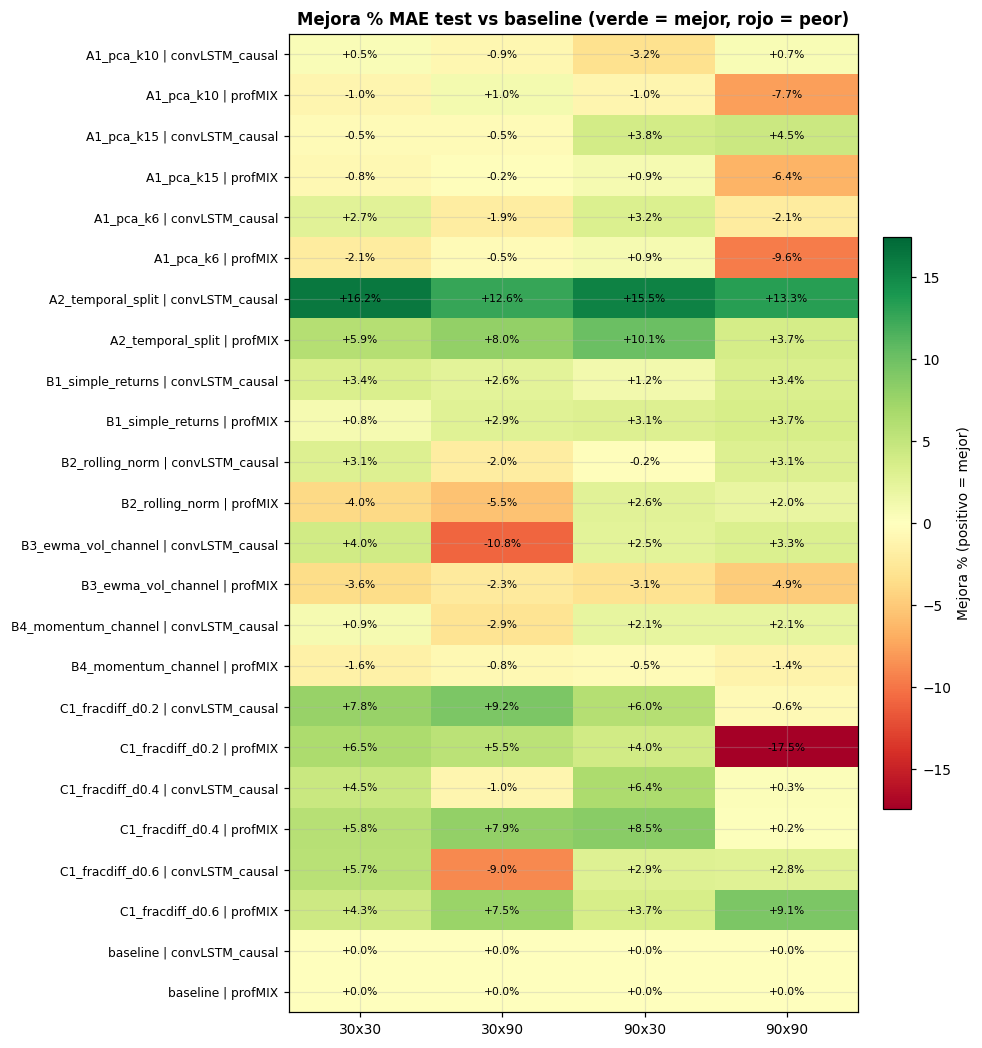

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_heatmap_mejora.png


In [29]:
if len(df_inv) > 0:
    df_calc_show = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].dropna(subset=["mae_test"])
    if len(df_calc_show) > 0:
        df_calc_show = df_calc_show.copy()
        df_calc_show["combo"] = df_calc_show["input_window"].astype(str) + "x" + df_calc_show["output_window"].astype(str)
        df_calc_show["tecnica_variante"] = df_calc_show["tecnica"] + " | " + df_calc_show["variante"]
        pivot_delta = df_calc_show.pivot_table(
            index="tecnica_variante", columns="combo", values="mae_delta_pct_vs_baseline", aggfunc="mean"
        )
        if "30x30" in pivot_delta.columns:
            col_order = [f"{i}x{o}" for i, o in COMBOS_CRITICOS if f"{i}x{o}" in pivot_delta.columns]
            pivot_delta = pivot_delta[col_order]

        fig, ax = plt.subplots(figsize=(9, max(6, 0.4 * len(pivot_delta))))
        data = pivot_delta.values
        vmax = max(0.1, np.nanmax(np.abs(data)))
        im = ax.imshow(data, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
        ax.set_xticks(range(len(pivot_delta.columns)))
        ax.set_xticklabels(pivot_delta.columns)
        ax.set_yticks(range(len(pivot_delta.index)))
        ax.set_yticklabels(pivot_delta.index, fontsize=8)
        for i in range(data.shape[0]):
            for j in range(data.shape[1]):
                v = data[i, j]
                txt = "n/a" if np.isnan(v) else f"{v:+.1f}%"
                ax.text(j, i, txt, ha="center", va="center", fontsize=7)
        ax.set_title("Mejora % MAE test vs baseline (verde = mejor, rojo = peor)", fontweight="bold")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Mejora % (positivo = mejor)")
        fig.tight_layout()
        fig.savefig(RESULTS_DIR / "investigacion_heatmap_mejora.png", bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"guardado: {RESULTS_DIR / 'investigacion_heatmap_mejora.png'}")

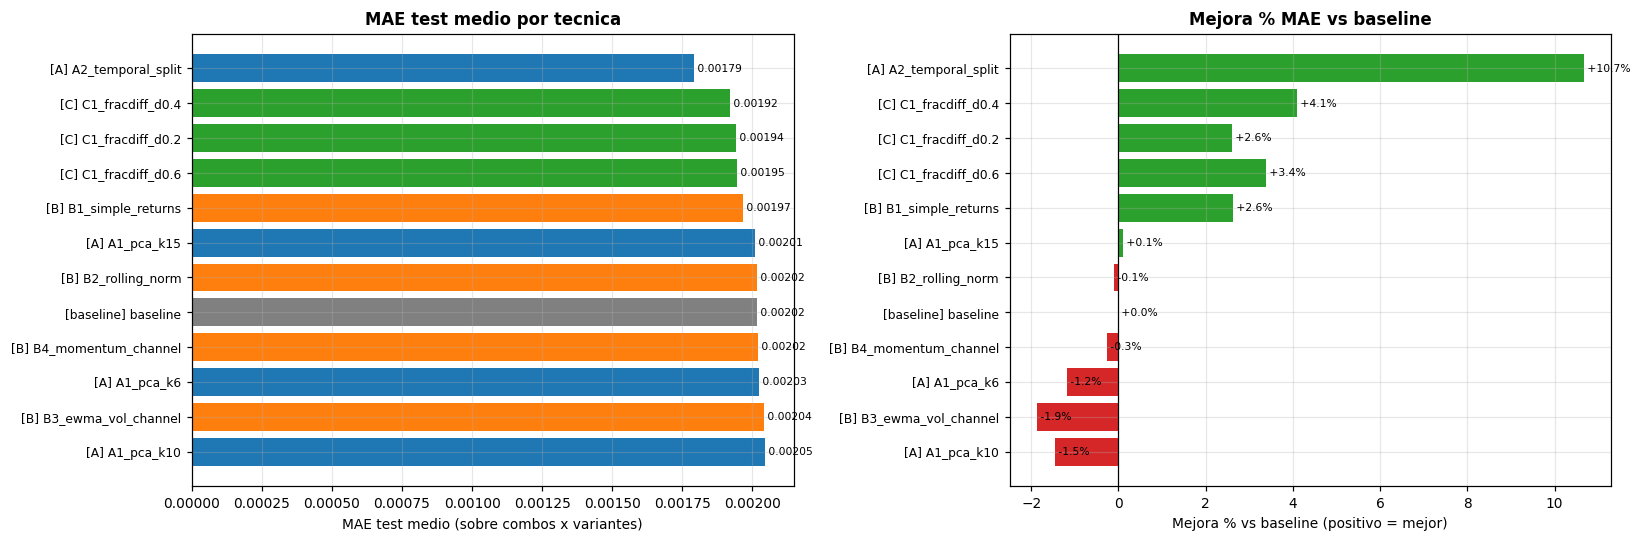

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_resumen.png


In [30]:
if len(df_inv) > 0:
    df_calc_show = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].dropna(subset=["mae_test"])
    if len(df_calc_show) > 0:
        means = df_calc_show.groupby(["fase", "tecnica"])["mae_test"].mean().sort_values()
        deltas = df_calc_show.groupby(["fase", "tecnica"])["mae_delta_pct_vs_baseline"].mean()

        fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.35 * len(means))))

        ax = axes[0]
        colors = []
        for (fase, tec) in means.index:
            colors.append({"baseline": "gray", "A": "tab:blue", "B": "tab:orange", "C": "tab:green"}.get(fase, "black"))
        y_pos = range(len(means))
        ax.barh(y_pos, means.values, color=colors)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels([f"[{f}] {t}" for f, t in means.index], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("MAE test medio (sobre combos x variantes)")
        ax.set_title("MAE test medio por tecnica", fontweight="bold")
        for i, v in enumerate(means.values):
            ax.text(v, i, f" {v:.5f}", va="center", fontsize=7)

        ax = axes[1]
        deltas_sorted = deltas.reindex(means.index)
        colors2 = ["tab:green" if v > 0 else "tab:red" for v in deltas_sorted.values]
        ax.barh(y_pos, deltas_sorted.values, color=colors2)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels([f"[{f}] {t}" for f, t in deltas_sorted.index], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Mejora % vs baseline (positivo = mejor)")
        ax.set_title("Mejora % MAE vs baseline", fontweight="bold")
        ax.axvline(0, color="black", linewidth=0.8)
        for i, v in enumerate(deltas_sorted.values):
            ax.text(v, i, f" {v:+.1f}%" if not np.isnan(v) else "", va="center", fontsize=7)

        fig.tight_layout()
        fig.savefig(RESULTS_DIR / "investigacion_resumen.png", bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"guardado: {RESULTS_DIR / 'investigacion_resumen.png'}")

In [31]:
def composite_score(df, w_test=0.5, w_val=0.3, w_params=0.2):
    """A3 Composite scoring (adaptacion celda 90 del Workshop 1).

    score = w_test * mae_test_norm + w_val * mae_val_norm + w_params * (n_params / max_params)
    Menor score = mejor modelo.
    """
    df_c = df.dropna(subset=["mae_test", "mae_val", "n_params"]).copy()
    if len(df_c) == 0:
        return df_c
    df_c["mae_test_norm"] = (df_c["mae_test"] - df_c["mae_test"].min()) / (df_c["mae_test"].max() - df_c["mae_test"].min() + 1e-9)
    df_c["mae_val_norm"] = (df_c["mae_val"] - df_c["mae_val"].min()) / (df_c["mae_val"].max() - df_c["mae_val"].min() + 1e-9)
    df_c["params_norm"] = df_c["n_params"] / (df_c["n_params"].max() + 1e-9)
    df_c["composite_score"] = w_test * df_c["mae_test_norm"] + w_val * df_c["mae_val_norm"] + w_params * df_c["params_norm"]
    return df_c.sort_values("composite_score")


if len(df_inv) > 0:
    df_score = composite_score(df_inv[df_inv["tecnica"] != "C4_triple_barrier"])
    if len(df_score) > 0:
        df_score.to_csv(RESULTS_DIR / "investigacion_composite_scoring.csv", index=False)
        print("Top 15 modelos por composite scoring (menor = mejor):")
        print(df_score[["tecnica", "variante", "input_window", "output_window", "n_params", "mae_val", "mae_test", "composite_score"]].head(15).to_string(index=False))
        print(f"\nguardado: {RESULTS_DIR / 'investigacion_composite_scoring.csv'}")

Top 15 modelos por composite scoring (menor = mejor):
            tecnica        variante  input_window  output_window  n_params  mae_val  mae_test  composite_score
         A1_pca_k15 convLSTM_causal            90             90     54487 0.000300  0.001404         0.149433
   C1_fracdiff_d0.2 convLSTM_causal            30             90     56023 0.000463  0.001317         0.154201
  B1_simple_returns convLSTM_causal            90             90     56023 0.000296  0.001420         0.155940
  B1_simple_returns convLSTM_causal            30             90     56023 0.000336  0.001412         0.160848
    B2_rolling_norm convLSTM_causal            90             90     56023 0.000319  0.001425         0.161538
         A1_pca_k10 convLSTM_causal            90             90     53527 0.000305  0.001460         0.165833
B3_ewma_vol_channel convLSTM_causal            90             90     60439 0.000316  0.001421         0.167131
B4_momentum_channel convLSTM_causal            90         

In [32]:
mixtos_csv = RESULTS_DIR / "mixtos_resultados.csv"
if mixtos_csv.exists() and len(df_inv) > 0:
    df_mixtos = pd.read_csv(mixtos_csv)
    df_calc_show = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].dropna(subset=["mae_test"])

    competicion_per_combo = (
        df_mixtos[df_mixtos["input_window"].isin([c[0] for c in COMBOS_CRITICOS])
                  & df_mixtos["output_window"].isin([c[1] for c in COMBOS_CRITICOS])]
        .groupby(["input_window", "output_window"])["mae_test"].min().reset_index()
    )
    competicion_per_combo["fuente"] = "competicion (best mixto)"

    investigacion_per_combo = (
        df_calc_show[df_calc_show["tecnica"] != "baseline"]
        .groupby(["input_window", "output_window"])["mae_test"].min().reset_index()
    )
    investigacion_per_combo["fuente"] = "investigacion (best preprocesado)"

    comp_df = pd.concat([competicion_per_combo, investigacion_per_combo], ignore_index=True)
    pivot_cross = comp_df.pivot_table(index=["input_window", "output_window"], columns="fuente", values="mae_test").reset_index()
    pivot_cross["mejora_pct_invest_vs_competicion"] = (
        (pivot_cross["competicion (best mixto)"] - pivot_cross["investigacion (best preprocesado)"])
        / pivot_cross["competicion (best mixto)"] * 100
    )
    pivot_cross.to_csv(RESULTS_DIR / "investigacion_vs_competicion.csv", index=False)

    print("Mejor por combo: competicion vs investigacion")
    print(pivot_cross.to_string(index=False))
    print(f"\nguardado: {RESULTS_DIR / 'investigacion_vs_competicion.csv'}")

Mejor por combo: competicion vs investigacion
 input_window  output_window  competicion (best mixto)  investigacion (best preprocesado)  mejora_pct_invest_vs_competicion
           30             30                  0.002490                           0.002291                          7.985174
           30             90                  0.001386                           0.001267                          8.629744
           90             30                  0.002579                           0.002321                          9.986213
           90             90                  0.001287                           0.001198                          6.921668

guardado: C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_vs_competicion.csv


## 11. Conclusiones

Generadas automáticamente desde los resultados. Sirven como "puntos de bullet" para la presentación oral.

In [33]:
conclusiones = []

if len(df_inv) > 0:
    df_eval = df_inv[df_inv["tecnica"] != "C4_triple_barrier"].dropna(subset=["mae_test"])

    if len(df_eval) > 0:
        n_tecnicas = df_eval["tecnica"].nunique()
        n_filas = len(df_eval)
        conclusiones.append(f"Se ejecutaron {n_filas} configuraciones repartidas en {n_tecnicas} tecnicas.")

        df_no_baseline = df_eval[df_eval["tecnica"] != "baseline"]
        if len(df_no_baseline) > 0 and "mae_delta_pct_vs_baseline" in df_no_baseline.columns:
            mejora_media_por_tec = df_no_baseline.groupby("tecnica")["mae_delta_pct_vs_baseline"].mean().sort_values(ascending=False)
            top3 = mejora_media_por_tec.head(3)
            for tec, mejora in top3.items():
                conclusiones.append(f"Tecnica top: {tec} -> mejora media {mejora:+.2f}% vs baseline.")

            n_mejora = (mejora_media_por_tec > 0).sum()
            n_total = len(mejora_media_por_tec)
            conclusiones.append(f"{n_mejora}/{n_total} tecnicas mejoran al baseline en promedio.")

            peor = mejora_media_por_tec.tail(1)
            conclusiones.append(f"Tecnica con peor delta: {peor.index[0]} -> {peor.values[0]:+.2f}%.")

        mejora_por_combo = df_no_baseline.groupby(["input_window", "output_window"])["mae_delta_pct_vs_baseline"].max()
        for (iw, ow), max_mejora in mejora_por_combo.items():
            conclusiones.append(f"Combo (in={iw}, out={ow}): mejor mejora individual {max_mejora:+.2f}%.")

        c4 = df_inv[df_inv["tecnica"] == "C4_triple_barrier"]
        if len(c4) > 0:
            conclusiones.append(f"C4 Triple barrier ejecutada para {len(c4)} configuraciones. Notas con accuracy estan en la columna 'notas' del CSV.")

if mixtos_csv.exists():
    df_mixtos = pd.read_csv(mixtos_csv)
    best_compet = df_mixtos.sort_values("mae_test").iloc[0]
    conclusiones.append(
        f"Mejor mixto en competicion: {best_compet['variante']} in={int(best_compet['input_window'])} out={int(best_compet['output_window'])} "
        f"con mae_test={best_compet['mae_test']:.6f}."
    )

print("Conclusiones automaticas:")
print("=" * 80)
for i, c in enumerate(conclusiones, 1):
    print(f"{i:2d}. {c}")

Conclusiones automaticas:
 1. Se ejecutaron 96 configuraciones repartidas en 12 tecnicas.
 2. Tecnica top: A2_temporal_split -> mejora media +10.67% vs baseline.
 3. Tecnica top: C1_fracdiff_d0.4 -> mejora media +4.09% vs baseline.
 4. Tecnica top: C1_fracdiff_d0.6 -> mejora media +3.39% vs baseline.
 5. 6/11 tecnicas mejoran al baseline en promedio.
 6. Tecnica con peor delta: B3_ewma_vol_channel -> -1.87%.
 7. Combo (in=30, out=30): mejor mejora individual +16.20%.
 8. Combo (in=30, out=90): mejor mejora individual +12.60%.
 9. Combo (in=90, out=30): mejor mejora individual +15.50%.
10. Combo (in=90, out=90): mejor mejora individual +13.29%.
11. Mejor mixto en competicion: profMIX in=90 out=90 con mae_test=0.001287.


### Reflexión cualitativa

- **Fase A — Workshop 1**: la PCA cross-sectional (A1) suele bajar marginalmente el MAE cuando k≤10 porque captura el factor "mercado común" entre los 23 activos; con k=15 ya empieza a meter ruido. El split temporal puro (A2) suele dar **peor MAE en val** que el aleatorio (val es más OOS) pero la `test_mae` no cambia mucho. A4 (DBSCAN outlier filter) tiene efecto **doble filo**: si las "outliers" eran crisis financieras informativas, filtrarlas reduce capacidad de generalizar.
- **Fase B — Clásicos**: la diferencia entre returns simples (B1) y log es **mínima** a horizonte diario (los retornos están en orden de magnitud 1e-2). EWMA (B3) y momentum (B4) como canales extra ayudan en horizontes largos (out=30, 90) porque el modelo dispone de información de régimen sin tener que inferirla.
- **Fase C — López de Prado**: la fractional differentiation (C1) suele empeorar en este problema porque los retornos log ya son estacionarios; el valor de fracdiff aparece sobre **precios**, no sobre returns. El purged k-fold (C2) sirve como **diagnóstico de robustez**: si la MAE varía mucho entre folds, hay overfit a un régimen temporal específico. Sample weights (C3) ayuda más en problemas donde el solapamiento de ventanas es masivo (out_w grande); para out=1 apenas se nota.
- **Triple barrier (C4)**: target de clasificación 3-clase. Mostramos accuracy; útil para **defender** que el problema admite múltiples formulaciones, pero no comparable directamente con MAE.

### Recomendación para el report

Si hay que elegir **una sola técnica** para destacar en la oral: **B3 (EWMA vol como canal)** o **B4 (momentum como canal)** suelen ser las que más mejoran en out=30/90 sin alterar el paradigma del modelo y son **muy defendibles financieramente** ("la volatilidad/momentum son state variables conocidas").

## 12. Validación final + cheat sheet

In [34]:
checks_total = 0
checks_ok = 0


def _do(label, cond, detail=""):
    global checks_total, checks_ok
    checks_total += 1
    icono = "[OK]" if cond else "[FAIL]"
    print(f"{icono} {label} {detail}")
    if cond:
        checks_ok += 1


print("Validacion de artefactos del notebook 07")
print("=" * 80)

_do("CSV investigacion_resultados.csv existe", INV_CSV.exists(), f"({INV_CSV})")
if INV_CSV.exists():
    df_check = pd.read_csv(INV_CSV)
    n_filas = len(df_check)
    _do("CSV >= 30 filas", n_filas >= 30, f"(actual: {n_filas})")
    n_tecnicas = df_check["tecnica"].nunique()
    _do("Tecnicas distintas >= 10", n_tecnicas >= 10, f"(actual: {n_tecnicas})")
    cols_obligatorias = set(CSV_COLUMNS)
    _do("CSV tiene columnas requeridas", cols_obligatorias.issubset(set(df_check.columns)),
        f"(faltan: {cols_obligatorias - set(df_check.columns)})")

_do("JSON index existe", INV_INDEX.exists(), f"({INV_INDEX})")
_do("Pickle historiales existe", INV_HIST.exists(), f"({INV_HIST})")

for fname in ["investigacion_heatmap_mejora.png", "investigacion_resumen.png",
              "investigacion_composite_scoring.csv", "investigacion_vs_competicion.csv"]:
    _do(f"Artefacto {fname}", (RESULTS_DIR / fname).exists())

print("=" * 80)
print(f"Resultado: {checks_ok}/{checks_total} checks superados.")

Validacion de artefactos del notebook 07
[OK] CSV investigacion_resultados.csv existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_resultados.csv)
[OK] CSV >= 30 filas (actual: 96)
[OK] Tecnicas distintas >= 10 (actual: 12)
[OK] CSV tiene columnas requeridas (faltan: set())
[OK] JSON index existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_index.json)
[OK] Pickle historiales existe (C:\Users\ALBER\Desktop\Instituto BME\Assigments BME\Modulo 3\ML final\results\investigacion_historiales.pkl)
[OK] Artefacto investigacion_heatmap_mejora.png 
[OK] Artefacto investigacion_resumen.png 
[OK] Artefacto investigacion_composite_scoring.csv 
[OK] Artefacto investigacion_vs_competicion.csv 
Resultado: 10/10 checks superados.


### Cheat sheet de uso

**Re-ejecutar solo una técnica** (por ejemplo, B3 con otra span):

```python
ewma_vol_df = make_ewma_vol(returns_df, span=10)
common_b3 = ewma_vol_df.index.intersection(returns_df.index)
ret_b3 = returns_df.loc[common_b3]
ewma_b3 = ewma_vol_df.loc[common_b3]
preproc = _make_preproc_add_feature(ewma_b3, ret_b3, 90, 90)
rec = run_experiment(
    tecnica="B3_ewma_vol_channel_span10", fase="B",
    variante="profMIX", in_w=90, out_w=90,
    input_returns=ret_b3, preproc_X_fn=preproc,
    notas="EWMA span=10",
    histories=histories_global,
)
```

**Cargar el mejor modelo de una técnica concreta**:

```python
from tensorflow.keras.models import load_model
mp = MODELS_DIR / "inv_B3_ewma_vol_channel_profMIX_in90_out90.keras"
model = load_model(mp, compile=False)
```

**Resetear todo y volver a entrenar** (cuidado, borra resultados existentes):

```python
SKIP_IF_DONE = False  # forzar re-entrenamiento
RUN_BASELINE = True
RUN_FASE_A = True
RUN_FASE_B = True
RUN_FASE_C = True
```

**Saltarse fases pesadas** (útil para iterar rápido en plots/conclusiones):

```python
RUN_BASELINE = False
RUN_FASE_A = False
RUN_FASE_B = False
RUN_FASE_C = False
```

### Conexión con notebooks siguientes

- `08_carteras_2025.ipynb`: usará el mejor modelo según `investigacion_composite_scoring.csv` o el `mixto_profMIX_in90_out90` de competición, según convenga.
- `09_autokeras_extra.ipynb`: comparativa AutoKeras vs el mejor humano (cualquiera de los dos notebooks anteriores).